## We will first code a simple attention

In [47]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Ganga
   [0.55, 0.87, 0.66], # is
   [0.57, 0.85, 0.64], # a
   [0.22, 0.58, 0.33], # river
   [0.77, 0.25, 0.10], # blue
   [0.05, 0.80, 0.55],# in
   [0.95,0.08,0.53]] # colour
)

In [48]:
input_query= inputs[0]
input_query

tensor([0.4300, 0.1500, 0.8900])

In [49]:
0.3686+0.089


0.4576

## Let us do a dot product between input_query and vector of "blue"

In [50]:
print(inputs[4])
res= 0
for idx,ele in enumerate(inputs[0]):
  print("ele:",ele)
  res += ele*inputs[4][idx]
  print(res)

tensor([0.7700, 0.2500, 0.1000])
ele: tensor(0.4300)
tensor(0.3311)
ele: tensor(0.1500)
tensor(0.3686)
ele: tensor(0.8900)
tensor(0.4576)


In [51]:
res = torch.dot(inputs[4],input_query)
res

tensor(0.4576)

## We will now calculate attention score

In [52]:
attention_score = torch.empty(inputs.shape[0])
for idx,ele in enumerate(inputs):
  attention_score[idx] = torch.dot(ele,input_query)

attention_score

tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.8922])

In [53]:
#This just to do normalization and make it optimized for training
normalized_attention_score = attention_score/attention_score.sum()
normalized_attention_score

tensor([0.1867, 0.1783, 0.1760, 0.0888, 0.0855, 0.1179, 0.1667])

In [54]:
print(normalized_attention_score.sum())

tensor(1.)


In [55]:
def softmax_naive(x):
  return torch.exp(x)/torch.exp(x).sum()
softmax_naive(attention_score)

tensor([0.1766, 0.1688, 0.1667, 0.1045, 0.1027, 0.1221, 0.1586])

## LEt us code simple attention

In [56]:
words = ['Ganga', 'is', 'a', 'river', 'blue', 'in', 'colour']

inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Ganga
    [0.55, 0.87, 0.66],  # is
    [0.57, 0.85, 0.64],  # a
    [0.22, 0.58, 0.33],  # river
    [0.77, 0.25, 0.10],  # blue
    [0.05, 0.80, 0.55],  # in
    [0.95, 0.08, 0.53],  # colour
])

# ── Step 1: Raw dot-product attention scores ──────────────────────────────────
# For every pair (query_i, key_j) compute dot product
# Shape: (7, 7)
raw_scores = torch.matmul(inputs, inputs.T)

In [57]:
# ── Step 2: Softmax → attention weights ──────────────────────────────────────
attention_weights = torch.softmax(raw_scores, dim=-1)

# ── Step 3: Context vectors (weighted sum of values) ─────────────────────────
# Each row of context_vectors is the context vector for that query token
print("Input shape", inputs.shape)
print("Attention weights shape", attention_weights.shape)
context_vectors = torch.matmul(attention_weights, inputs)
print(context_vectors)

Input shape torch.Size([7, 3])
Attention weights shape torch.Size([7, 7])
tensor([[0.5226, 0.5117, 0.5712],
        [0.5030, 0.5827, 0.5637],
        [0.5053, 0.5797, 0.5625],
        [0.4931, 0.5635, 0.5485],
        [0.5528, 0.5003, 0.5272],
        [0.4706, 0.5937, 0.5611],
        [0.5692, 0.4772, 0.5459]])


In [58]:
# ── Step 4: Pick a query token to inspect closely ────────────────────────────
query_idx = 1   # ← change this to inspect any token (0=Ganga, 1=is, ...)
query_word = words[query_idx]
attention_score = attention_weights[query_idx]   # shape: (7,)
context_vector  = context_vectors[query_idx]     # shape: (3,)

# ── Step 5: Loop (your original code, kept intact) ───────────────────────────
print(f"--- Context Vector for query: '{query_word}' ---\n")
context_vector_loop = torch.zeros(inputs[query_idx].shape)

for i, x_i in enumerate(inputs):
    current_attention_score = attention_score[i]
    weighted_x_i = current_attention_score * x_i
    context_vector_loop += weighted_x_i

    print(f"Step {i+1}: attn={current_attention_score:.4f}  "
          f"x_{i}={x_i.numpy()}  "
          f"weighted={weighted_x_i.detach().numpy().round(4)}")

print(f"\nFinal context vector : {context_vector_loop.detach().numpy().round(4)}")
print(f"matmul cross-check   : {context_vector.detach().numpy().round(4)}")


--- Context Vector for query: 'is' ---

Step 1: attn=0.1219  x_0=[0.43 0.15 0.89]  weighted=[0.0524 0.0183 0.1085]
Step 2: attn=0.2093  x_1=[0.55 0.87 0.66]  weighted=[0.1151 0.1821 0.1381]
Step 3: attn=0.2052  x_2=[0.57 0.85 0.64]  weighted=[0.117  0.1744 0.1313]
Step 4: attn=0.1091  x_3=[0.22 0.58 0.33]  weighted=[0.024  0.0633 0.036 ]
Step 5: attn=0.0952  x_4=[0.77 0.25 0.1 ]  weighted=[0.0733 0.0238 0.0095]
Step 6: attn=0.1391  x_5=[0.05 0.8  0.55]  weighted=[0.007  0.1113 0.0765]
Step 7: attn=0.1204  x_6=[0.95 0.08 0.53]  weighted=[0.1143 0.0096 0.0638]

Final context vector : [0.503  0.5827 0.5637]
matmul cross-check   : [0.503  0.5827 0.5637]


## Visualize the attention

In [59]:
# ── Attention: dot product → softmax ─────────────────────────────────────────
raw_scores        = torch.matmul(inputs, inputs.T)      # (7, 7)
attention_weights = torch.softmax(raw_scores, dim=-1)   # (7, 7)

# ── Your original loop (query = "is") ────────────────────────────────────────
query_idx  = 1
query      = inputs[query_idx]
attn_score = attention_weights[query_idx]

context_vector = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vector += attn_score[i] * x_i

print(f"Query: '{words[query_idx]}'")
print(f"Context vector: {context_vector.detach().numpy().round(4)}")


Query: 'is'
Context vector: [0.503  0.5827 0.5637]


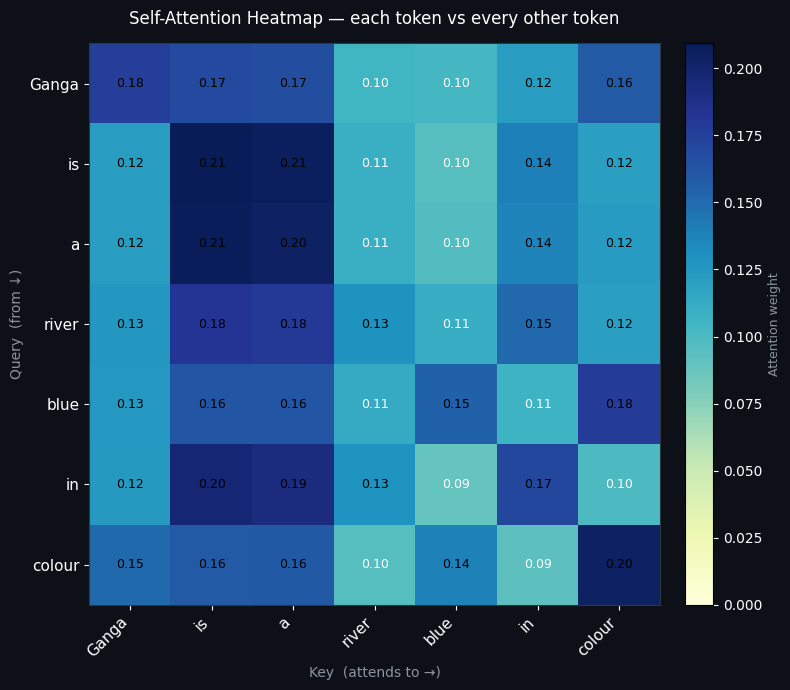

In [60]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
attn_np = attention_weights.detach().numpy()

fig, ax = plt.subplots(figsize=(8, 7), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

im = ax.imshow(attn_np, cmap='YlGnBu', aspect='auto', vmin=0, vmax=attn_np.max())

ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha='right', color='white', fontsize=11)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, color='white', fontsize=11)
ax.set_xlabel('Key  (attends to →)', color='#8b949e', fontsize=10)
ax.set_ylabel('Query  (from ↓)',     color='#8b949e', fontsize=10)
ax.set_title('Self-Attention Heatmap — each token vs every other token',
             color='white', fontsize=12, pad=14)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

# value annotations inside each cell
for i in range(len(words)):
    for j in range(len(words)):
        val = attn_np[i, j]
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center', fontsize=9,
                color='black' if val > 0.12 else 'white')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
cbar.set_label('Attention weight', color='#8b949e', fontsize=9)

plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## Implementing self attention step by step

In [61]:
x_2 = inputs[1] #[1,3]
d_in= inputs.shape[1] #[3]
d_out = 2

In [62]:
print(x_2)
print(d_in)
print(d_out)

tensor([0.5500, 0.8700, 0.6600])
3
2


In [63]:
# @title
# ============================================================
# PART 1: THE HUMAN STORY — Q, K, V INTUITION
# Paste this in a Colab CODE cell and run it
# ============================================================
from IPython.display import display, HTML

display(HTML("""
<style>
.sa-wrap{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;background:#0f172a;color:#e2e8f0;padding:24px;border-radius:16px;max-width:860px;margin:10px auto}
.sa-wrap h1{font-size:28px;font-weight:800;background:linear-gradient(135deg,#f43f5e,#6366f1,#10b981);-webkit-background-clip:text;-webkit-text-fill-color:transparent;margin:0 0 4px;text-align:center}
.sa-wrap h2{font-size:22px;font-weight:700;color:#e2e8f0;margin:18px 0 8px;border-bottom:1px solid #1e293b;padding-bottom:6px}
.sa-wrap h3{font-size:17px;font-weight:700;margin:14px 0 6px}
.sa-wrap p,.sa-wrap li{font-size:14px;line-height:1.7;color:#cbd5e1}
.sa-wrap .subtitle{color:#94a3b8;font-size:16px;text-align:center;margin-bottom:16px}
.sa-wrap .pills{display:flex;gap:6px;flex-wrap:wrap;justify-content:center;margin:12px 0}
.sa-wrap .pill{padding:5px 12px;border-radius:8px;font-weight:600;font-size:13px}
.sa-wrap .card{background:#1e293b;border-radius:12px;padding:14px;border:1px solid #334155;margin:10px 0}
.sa-wrap .analogy{margin:12px 0}
.sa-wrap .analogy-head{display:flex;gap:10px;align-items:flex-start;margin-bottom:6px}
.sa-wrap .analogy-icon{min-width:36px;height:36px;border-radius:10px;background:#1e293b;display:flex;align-items:center;justify-content:center;font-size:18px;border:1px solid #334155}
.sa-wrap .geo-box{margin-left:46px;padding:8px 12px;border-left:3px solid;border-radius:0 8px 8px 0;margin-bottom:6px}
.sa-wrap .example-box{margin-left:46px;padding:6px 12px;background:#0f172a;border-radius:8px;border:1px solid #334155;margin-bottom:6px}
.sa-wrap table{border-collapse:collapse;width:100%;margin:10px 0}
.sa-wrap th,.sa-wrap td{padding:8px 10px;font-size:12px;text-align:center;border:1px solid #334155}
.sa-wrap th{background:#1e293b;color:#94a3b8;font-weight:600}
.sa-wrap tr:nth-child(even){background:#1e293b}
.sa-wrap tr:nth-child(odd){background:#0f172a}
.sa-wrap .highlight-box{border-radius:12px;padding:14px;margin:12px 0}
.sa-wrap .punchline{background:linear-gradient(135deg,#1e1b4b,#172554);border-radius:14px;padding:16px;border:1px solid #6366f140;text-align:center;margin:16px 0}
.sa-wrap strong{color:#e2e8f0}
.sa-wrap em{color:#94a3b8}
</style>

<div class="sa-wrap">
  <h1>&#x1F9ED; Self-Attention: Query, Key, Value</h1>
  <p class="subtitle">Part 1: The Human Story &mdash; Building Intuition</p>

  <div class="pills">
    <span class="pill" style="background:#f43f5e15;border:1px solid #f43f5e40;color:#f43f5e">Ganga</span>
    <span class="pill" style="background:#a855f715;border:1px solid #a855f740;color:#a855f7">is</span>
    <span class="pill" style="background:#64748b15;border:1px solid #64748b40;color:#64748b">a</span>
    <span class="pill" style="background:#3b82f615;border:1px solid #3b82f640;color:#3b82f6">river</span>
    <span class="pill" style="background:#06b6d415;border:1px solid #06b6d440;color:#06b6d4">blue</span>
    <span class="pill" style="background:#64748b15;border:1px solid #64748b40;color:#64748b">in</span>
    <span class="pill" style="background:#f59e0b15;border:1px solid #f59e0b40;color:#f59e0b">colour</span>
  </div>

  <!-- COCKTAIL PARTY -->
  <h2>&#x1F389; The Big Picture: A Cocktail Party</h2>
  <p>Imagine you are at a <strong>cocktail party</strong>. There are 7 people (our 7 words). Each person needs to have a conversation and come away with a richer understanding. Here is how it works:</p>

  <!-- QUERY -->
  <div class="analogy">
    <div class="analogy-head">
      <div class="analogy-icon">&#x1F50D;</div>
      <p>Each person has a set of questions in mind &mdash; things they want to learn. "Ganga" wants to know: <em>"Am I a place? A river? What describes me?"</em> These questions are the <strong style="color:#6366f1">Query</strong>.</p>
    </div>
    <div class="geo-box" style="border-color:#6366f1;background:#6366f110">
      <p style="font-size:12px">&#x1F4D0; <strong>Geometrically:</strong> The query vector points in the <strong>direction of the information</strong> this token is searching for. It is like a compass needle &mdash; its direction in vector space represents the type of information needed.</p>
    </div>
  </div>

  <div class="card">
    <h3 style="color:#6366f1">&#x1F50D; Deep Dive: The Query &mdash; Your Inner Curiosity</h3>
    <p>Think of the query as your <strong>inner curiosity</strong>. When you read "Ganga", your brain immediately starts asking: <em>"What kind of thing is Ganga? Where is it? What is it like?"</em> You do not ask these consciously &mdash; your brain does it automatically.</p>
    <table>
      <tr><th>Token</th><th>What its Query is asking</th></tr>
      <tr><td style="color:#f43f5e;font-weight:700">Ganga</td><td>"Am I a place? A river? What are my properties?"</td></tr>
      <tr><td style="color:#3b82f6;font-weight:700">river</td><td>"Who am I describing? What subject do I belong to?"</td></tr>
      <tr><td style="color:#06b6d4;font-weight:700">blue</td><td>"What thing am I describing? What noun do I modify?"</td></tr>
      <tr><td style="color:#f59e0b;font-weight:700">colour</td><td>"What is my role here? What am I categorizing?"</td></tr>
    </table>
  </div>

  <!-- KEY -->
  <div class="analogy" style="margin-top:16px">
    <div class="analogy-head">
      <div class="analogy-icon">&#x1F511;</div>
      <p>Each person also wears a <strong>name tag</strong> describing what they know. "river" wears a tag saying <em>"I am a noun, a water body, a geographic feature."</em> This name tag is the <strong style="color:#f59e0b">Key</strong>.</p>
    </div>
    <div class="geo-box" style="border-color:#f59e0b;background:#f59e0b10">
      <p style="font-size:12px">&#x1F4D0; <strong>Geometrically:</strong> The key vector points in the direction that <strong>advertises what this token contains</strong>. When a query and key point in the same direction, it means what one needs is what the other offers.</p>
    </div>
  </div>

  <div class="card">
    <h3 style="color:#f59e0b">&#x1F511; Deep Dive: The Key &mdash; Your Reputation</h3>
    <p>If the query is your <em>curiosity</em>, the key is your <strong>reputation</strong> &mdash; what others know about you before you even speak.</p>
    <div style="display:flex;gap:8px;flex-wrap:wrap;margin:10px 0">
      <span class="pill" style="background:#f43f5e10;border:1px solid #f43f5e30"><strong style="color:#f43f5e">Ganga:</strong> <span style="color:#94a3b8;font-size:11px">proper noun, entity, place</span></span>
      <span class="pill" style="background:#3b82f610;border:1px solid #3b82f630"><strong style="color:#3b82f6">river:</strong> <span style="color:#94a3b8;font-size:11px">noun, water body, geography</span></span>
      <span class="pill" style="background:#06b6d410;border:1px solid #06b6d430"><strong style="color:#06b6d4">blue:</strong> <span style="color:#94a3b8;font-size:11px">adjective, color, visual</span></span>
      <span class="pill" style="background:#f59e0b10;border:1px solid #f59e0b30"><strong style="color:#f59e0b">colour:</strong> <span style="color:#94a3b8;font-size:11px">abstract noun, visual property</span></span>
    </div>
    <p>When "Ganga" scans the room looking for context (its query), it reads everyone's name tag (their keys). <strong>"river" tag screams relevance.</strong> "is" tag? Not so much.</p>
  </div>

  <!-- VALUE -->
  <div class="analogy" style="margin-top:16px">
    <div class="analogy-head">
      <div class="analogy-icon">&#x1F4E6;</div>
      <p>When two people decide to talk (query matches key), the actual knowledge shared is the <strong style="color:#10b981">Value</strong>. "river" does not just say "I am a noun" &mdash; it shares its rich meaning: water, flow, geography.</p>
    </div>
    <div class="geo-box" style="border-color:#10b981;background:#10b98110">
      <p style="font-size:12px">&#x1F4D0; <strong>Geometrically:</strong> The value vector lives in "content space" &mdash; a different space optimized for carrying meaning. The output is a <strong>weighted blend (linear combination)</strong> of these value vectors.</p>
    </div>
  </div>

  <div class="card">
    <h3 style="color:#10b981">&#x1F4E6; Deep Dive: The Value &mdash; Your Actual Knowledge</h3>
    <p>"river" <em>key</em> just says "geographic water body" (enough to match). But "river" <em>value</em> carries the full payload: flowing water, banks, current, ecosystem, geography.</p>
    <p style="margin-top:8px"><strong>"Ganga" does not just talk to one word.</strong> It talks to everyone at once, but listens more to some than others. Its final understanding is a <em>blend</em> of everyone's value, proportional to how relevant they were.</p>
  </div>

  <!-- COMPARISON TABLE -->
  <h2>&#x1F3AF; Q vs K vs V: The Complete Comparison</h2>
  <div style="overflow-x:auto">
    <table>
      <thead>
        <tr>
          <th></th>
          <th style="background:#6366f115;color:#6366f1">&#x1F50D; Query (Q)</th>
          <th style="background:#f59e0b15;color:#f59e0b">&#x1F511; Key (K)</th>
          <th style="background:#10b98115;color:#10b981">&#x1F4E6; Value (V)</th>
        </tr>
      </thead>
      <tbody>
        <tr><td style="text-align:left;font-weight:600;color:#94a3b8">Human Analogy</td><td style="color:#a5b4fc">Your questions / curiosity</td><td style="color:#fcd34d">Your name tag / reputation</td><td style="color:#6ee7b7">Your actual knowledge</td></tr>
        <tr><td style="text-align:left;font-weight:600;color:#94a3b8">Role in Sentence</td><td style="color:#a5b4fc">What context do I need?</td><td style="color:#fcd34d">What context can I provide?</td><td style="color:#6ee7b7">Here is my actual meaning</td></tr>
        <tr><td style="text-align:left;font-weight:600;color:#94a3b8">For "Ganga"</td><td style="color:#a5b4fc">Seeking: entity type, descriptors</td><td style="color:#fcd34d">Offering: proper noun, place</td><td style="color:#6ee7b7">Carrying: sacred river meaning</td></tr>
        <tr><td style="text-align:left;font-weight:600;color:#94a3b8">Geometric Role</td><td style="color:#a5b4fc">Direction of information need</td><td style="color:#fcd34d">Direction of information offer</td><td style="color:#6ee7b7">Content payload vector</td></tr>
        <tr><td style="text-align:left;font-weight:600;color:#94a3b8">Interacts With</td><td style="color:#a5b4fc">Keys (via dot product)</td><td style="color:#fcd34d">Queries (via dot product)</td><td style="color:#6ee7b7">Attention weights (weighted sum)</td></tr>
        <tr><td style="text-align:left;font-weight:600;color:#94a3b8">Space Metaphor</td><td style="color:#a5b4fc">Compass pointing to needs</td><td style="color:#fcd34d">Beacon broadcasting content</td><td style="color:#6ee7b7">Package of information</td></tr>
      </tbody>
    </table>
  </div>

  <!-- PUNCHLINE -->
  <div class="punchline">
    <p style="font-size:14px;line-height:1.7"><strong>Q and K are the matchmakers</strong> &mdash; they decide WHO talks to whom and HOW MUCH.<br>
    <strong>V is the conversation content</strong> &mdash; it is WHAT actually gets shared.<br>
    The output is the result of listening to everyone, weighted by relevance.</p>
  </div>
</div>
"""))


In [64]:
torch.manual_seed(123)
w_q = torch.nn.Parameter(torch.randn(d_in,d_out))
w_k= torch.nn.Parameter(torch.randn(d_in,d_out))
w_v =torch.nn.Parameter(torch.randn(d_in,d_out))

In [65]:
print(w_q)
print(w_k)
print(w_v)

Parameter containing:
tensor([[-0.1115,  0.1204],
        [-0.3696, -0.2404],
        [-1.1969,  0.2093]], requires_grad=True)
Parameter containing:
tensor([[-0.9724, -0.7550],
        [ 0.3239, -0.1085],
        [ 0.2103, -0.3908]], requires_grad=True)
Parameter containing:
tensor([[ 0.2350,  0.6653],
        [ 0.3528,  0.9728],
        [-0.0386, -0.8861]], requires_grad=True)


In [66]:
q_2 = x_2 @ w_q #[1,3]*[3,2]= [1,2]
k_2 = x_2 @ w_k #[1,3]*[3,2]= [1,2]
v_2 = x_2 @ w_v #[1,3]*[3,2]= [1,2]

In [67]:
print(q_2)
print(k_2)
print(v_2)

tensor([-1.1729, -0.0048], grad_fn=<SqueezeBackward4>)
tensor([-0.1142, -0.7676], grad_fn=<SqueezeBackward4>)
tensor([0.4107, 0.6274], grad_fn=<SqueezeBackward4>)


In [68]:
v_2

tensor([0.4107, 0.6274], grad_fn=<SqueezeBackward4>)

In [69]:
query_2 = x_2 @ w_q # _2 because it's with respect to the 2nd input element
key_2 = x_2 @ w_k
value_2 = x_2 @ w_v

print(query_2)

tensor([-1.1729, -0.0048], grad_fn=<SqueezeBackward4>)


## LEt us do it for all tokens

In [70]:
# @title
# ============================================================
# PART 2: THE GEOMETRIC TRUTH — LINEAR TRANSFORMATIONS
# Paste this in a Colab CODE cell and run it
# ============================================================
from IPython.display import display, HTML

display(HTML("""
<style>
.sa2{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;background:#0f172a;color:#e2e8f0;padding:24px;border-radius:16px;max-width:860px;margin:10px auto}
.sa2 h1{font-size:28px;font-weight:800;background:linear-gradient(135deg,#6366f1,#3b82f6,#10b981);-webkit-background-clip:text;-webkit-text-fill-color:transparent;margin:0 0 4px;text-align:center}
.sa2 h2{font-size:22px;font-weight:700;color:#e2e8f0;margin:18px 0 8px;border-bottom:1px solid #1e293b;padding-bottom:6px}
.sa2 h3{font-size:16px;font-weight:700;margin:10px 0 6px}
.sa2 p,.sa2 li{font-size:14px;line-height:1.7;color:#cbd5e1}
.sa2 .subtitle{color:#94a3b8;font-size:16px;text-align:center;margin-bottom:16px}
.sa2 .card{background:#1e293b;border-radius:12px;padding:14px;border:1px solid #334155;margin:10px 0}
.sa2 .tgrid{display:flex;gap:12px;flex-wrap:wrap;justify-content:center;margin:12px 0}
.sa2 .tcard{flex:1 1 200px;background:#1e293b;border-radius:14px;padding:14px;text-align:center;border:1px solid}
.sa2 .tcard-icon{font-size:28px;margin-bottom:4px}
.sa2 .tcard-title{font-weight:700;font-size:15px;margin-bottom:6px}
.sa2 .tcard-desc{font-size:12px;color:#94a3b8;line-height:1.5}
.sa2 .step{padding:8px 12px;border-left:3px solid;background:#0f172a;border-radius:0 8px 8px 0;margin:6px 0}
.sa2 .step-l{font-weight:600;font-size:13px}
.sa2 .step-d{font-size:12px;color:#94a3b8;margin-top:2px}
.sa2 .code-block{background:#0f172a;border:1px solid #334155;border-radius:10px;padding:12px;margin:10px 0;font-family:monospace;font-size:12px;overflow-x:auto;white-space:pre;color:#a5b4fc;line-height:1.6}
.sa2 .highlight{border-radius:12px;padding:12px;margin:10px 0}
.sa2 .space-row{display:flex;gap:14px;flex-wrap:wrap;justify-content:center;align-items:center;margin:14px 0}
.sa2 .space-arrow{display:flex;flex-direction:column;align-items:center;gap:2px;font-weight:800}
.sa2 table{border-collapse:collapse;width:100%;margin:10px 0}
.sa2 th,.sa2 td{padding:8px 10px;font-size:12px;border:1px solid #334155}
.sa2 th{background:#1e293b;color:#94a3b8;font-weight:600;text-align:left}
.sa2 tr:nth-child(even){background:#1e293b}
.sa2 tr:nth-child(odd){background:#0f172a}
.sa2 .hint{background:#0f172a;border-radius:10px;padding:10px;border:1px solid #334155;margin:10px 0}
.sa2 strong{color:#e2e8f0}
.sa2 em{color:#94a3b8}
.sa2 .section-card{border-radius:12px;padding:12px;margin:8px 0}
</style>

<div class="sa2">
  <h1>&#x1F4D0; Self-Attention: Q, K, V</h1>
  <p class="subtitle">Part 2: The Geometric Truth &mdash; Linear Transformations</p>

  <!-- WHAT MATRIX MULTIPLY DOES -->
  <h2>&#x1F504; What Does Multiplying by W Do to a Vector?</h2>
  <p>Multiplying by a weight matrix is like putting on <strong>special glasses</strong> &mdash; each matrix (W_Q, W_K, W_V) shows you the same word from a different angle. It performs three operations simultaneously:</p>

  <div class="tgrid">
    <div class="tcard" style="border-color:#6366f130">
      <div class="tcard-icon">&#x1F504;</div>
      <div class="tcard-title" style="color:#6366f1">Rotate</div>
      <div class="tcard-desc">Spin the vector to re-orient it. "Ganga" in embedding space points one way; in query-space it gets spun to point toward "what I need."</div>
    </div>
    <div class="tcard" style="border-color:#f59e0b30">
      <div class="tcard-icon">&#x1F4CF;</div>
      <div class="tcard-title" style="color:#f59e0b">Scale + Stretch</div>
      <div class="tcard-desc">Some dimensions get amplified, others shrunk. W_Q might amplify the "seeking-entity" dimension and shrink "word-frequency".</div>
    </div>
    <div class="tcard" style="border-color:#10b98130">
      <div class="tcard-icon">&#x1F3AF;</div>
      <div class="tcard-title" style="color:#10b981">Project</div>
      <div class="tcard-desc">Drop from 4D to 3D &mdash; keep only the dimensions relevant for the purpose. Query-space keeps "information-need" dimensions.</div>
    </div>
  </div>

  <div class="hint">
    <p style="font-size:13px;color:#e2e8f0">&#x1F4A1; <strong>Three different glasses for the same word:</strong> W_Q shows what the word <em>needs</em>. W_K shows what it <em>offers</em>. W_V shows what it actually <em>means</em>. Same input, three different views &mdash; that is the power of learned linear transformations.</p>
  </div>

  <!-- Q TRANSFORM -->
  <h2 style="color:#6366f1">&#x1F50D; Q = X &middot; W_Q &mdash; Projecting into "Need Space"</h2>

  <div class="step" style="border-color:#6366f1">
    <div class="step-l" style="color:#6366f1">Each column of W_Q is a basis vector</div>
    <div class="step-d">Together they define a new coordinate system &mdash; the "query space". The columns are the axes of this new space.</div>
  </div>
  <div class="step" style="border-color:#6366f1">
    <div class="step-l" style="color:#6366f1">Multiplying x &middot; W_Q is a change of basis</div>
    <div class="step-d">The token embedding gets re-expressed in this new coordinate system. Dimensions that matter for seeking information get amplified.</div>
  </div>
  <div class="step" style="border-color:#6366f1">
    <div class="step-l" style="color:#6366f1">The resulting q vector is a direction</div>
    <div class="step-d">Its direction in query-space encodes "what I need." Two tokens needing similar info will have q vectors pointing the same way.</div>
  </div>

  <div class="code-block">Embedding Space (4D)         &times; W_Q          Query Space (3D)
  "Ganga" &rarr; [0.9, 0.4, 0.7, 0.2]   &rarr;   [0.55, 1.01, 0.97]
  "river" &rarr; [0.8, 0.5, 0.9, 0.3]   &rarr;   [0.60, 1.11, 1.01]
  "blue"  &rarr; [0.3, 0.7, 0.6, 0.8]   &rarr;   [0.94, 0.87, 1.12]</div>

  <div class="highlight" style="background:#6366f110;border:1px solid #6366f130">
    <p style="color:#a5b4fc;font-size:13px">Notice: "Ganga" and "river" have <strong>similar query vectors</strong> &mdash; both are entity-type words that need similar context!</p>
  </div>

  <!-- K TRANSFORM -->
  <h2 style="color:#f59e0b">&#x1F511; K = X &middot; W_K &mdash; Projecting into "Offer Space"</h2>
  <p>K lives in the <strong>same dimensional space as Q</strong> (both d_k-dimensional) so dot products work. But <strong>W_K &ne; W_Q</strong> &mdash; a different rotation! This enables <strong>asymmetry</strong>: what you seek &ne; what you offer.</p>

  <div class="code-block">Embedding Space (4D)         &times; W_K          Key Space (3D)
  "Ganga" &rarr; [0.9, 0.4, 0.7, 0.2]   &rarr;   [0.79, 0.53, 0.81]
  "river" &rarr; [0.8, 0.5, 0.9, 0.3]   &rarr;   [1.24, 0.67, 0.92]
  "blue"  &rarr; [0.3, 0.7, 0.6, 0.8]   &rarr;   [0.94, 1.14, 0.68]</div>

  <div class="hint">
    <p style="color:#f59e0b;font-size:12px">&#x1F511; <strong>Why Q &ne; K for the same word?</strong> What "river" is <em>looking for</em> (maybe verbs or subjects) is totally different from what "river" <em>offers</em> to others (noun, geographic context). Different transforms capture this naturally.</p>
  </div>

  <!-- V TRANSFORM -->
  <h2 style="color:#10b981">&#x1F4E6; V = X &middot; W_V &mdash; Projecting into "Content Space"</h2>
  <p><strong>V-space carries the payload.</strong> Q and K are designed for matching. V-space is designed for <strong>carrying meaning forward</strong>. V can even have a different dimensionality (d_v &ne; d_k).</p>

  <div class="code-block">Embedding Space (4D)         &times; W_V          Value Space (3D)
  "Ganga" &rarr; [0.9, 0.4, 0.7, 0.2]   &rarr;   [0.62, 0.72, 0.53]
  "river" &rarr; [0.8, 0.5, 0.9, 0.3]   &rarr;   [0.99, 0.75, 0.85]
  "blue"  &rarr; [0.3, 0.7, 0.6, 0.8]   &rarr;   [0.95, 0.51, 0.79]</div>

  <!-- WHY THREE SPACES -->
  <h2>&#x1F914; Why Three Separate Spaces?</h2>
  <div class="card">
    <p>Imagine if we used the <em>same</em> vector for both querying and being queried. Then a token would always attend most to <strong>itself</strong> (a vector is maximally aligned with itself). That is useless &mdash; the whole point is to gather context from <em>other</em> tokens.</p>
    <p style="margin-top:8px">By using different transforms, the model can learn that "Ganga" <em>query</em> points toward "geographic entity" while "Ganga" <em>key</em> points toward "proper noun" &mdash; <strong>different directions!</strong> This breaks the self-attention trap.</p>
  </div>

  <div class="section-card" style="background:#a855f708;border:1px solid #a855f730">
    <h3 style="color:#a855f7">Q-space &amp; K-space: The Matchmaking Geometry</h3>
    <p style="font-size:13px">Q and K are in the same d_k-dimensional space (so dot products work), but different rotations (W_Q &ne; W_K) allow <strong>asymmetric matching</strong>. What "Ganga" seeks is different from what "Ganga" offers. Like at a job fair: your resume (key) highlights different things than your wish list (query).</p>
  </div>

  <div class="section-card" style="background:#10b98108;border:1px solid #10b98130">
    <h3 style="color:#10b981">V-space: The Content Geometry</h3>
    <p style="font-size:13px">V can even have a different dimensionality. It is optimized for carrying meaning &mdash; not for matching. Q and K are the phone directory (helping you find the right person), while V is the actual phone conversation (the content exchanged). You would not design a phone book and a conversation the same way.</p>
  </div>
</div>
"""))


In [71]:
keys = inputs @ w_k
values = inputs @ w_v

print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([7, 2])
values.shape: torch.Size([7, 2])


In [72]:
keys_2 = keys[1] # Python starts index at 0
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(0.1376, grad_fn=<DotBackward0>)


In [73]:
attn_scores_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

tensor([ 0.2172,  0.1376,  0.1730, -0.0491,  0.7616, -0.3809,  0.9268],
       grad_fn=<SqueezeBackward4>)


In [74]:
# @title
# ============================================================
# PART 3: DOT PRODUCTS, SOFTMAX & OUTPUT
# Paste this in a Colab CODE cell and run it
# ============================================================
from IPython.display import display, HTML

display(HTML("""
<style>
.sa3{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;background:#0f172a;color:#e2e8f0;padding:24px;border-radius:16px;max-width:860px;margin:10px auto}
.sa3 h1{font-size:28px;font-weight:800;background:linear-gradient(135deg,#ec4899,#3b82f6,#f43f5e);-webkit-background-clip:text;-webkit-text-fill-color:transparent;margin:0 0 4px;text-align:center}
.sa3 h2{font-size:22px;font-weight:700;color:#e2e8f0;margin:18px 0 8px;border-bottom:1px solid #1e293b;padding-bottom:6px}
.sa3 h3{font-size:16px;font-weight:700;margin:10px 0 6px}
.sa3 p{font-size:14px;line-height:1.7;color:#cbd5e1}
.sa3 .subtitle{color:#94a3b8;font-size:16px;text-align:center;margin-bottom:16px}
.sa3 .card{background:#1e293b;border-radius:12px;padding:14px;border:1px solid #334155;margin:10px 0}
.sa3 .formula{background:linear-gradient(135deg,#1e1b4b,#172554);border-radius:14px;padding:16px;border:1px solid #6366f140;text-align:center;margin:14px 0;font-family:monospace;font-size:16px;color:#e2e8f0;letter-spacing:0.5px}
.sa3 .dot-grid{display:flex;gap:10px;flex-wrap:wrap;justify-content:center;margin:12px 0}
.sa3 .dot-card{flex:1 1 200px;border-radius:12px;padding:12px;text-align:center;border:1px solid #334155}
.sa3 .dot-title{font-weight:600;font-size:13px;margin-bottom:4px}
.sa3 .dot-visual{font-size:28px;margin:8px 0}
.sa3 .dot-note{font-family:monospace;font-size:12px;color:#94a3b8}
.sa3 table{border-collapse:collapse;width:100%;margin:10px 0}
.sa3 th,.sa3 td{padding:8px 10px;font-size:12px;border:1px solid #334155;text-align:center}
.sa3 th{background:#1e293b;color:#94a3b8;font-weight:600}
.sa3 tr:nth-child(even){background:#1e293b}
.sa3 tr:nth-child(odd){background:#0f172a}
.sa3 .highlight{border-radius:12px;padding:12px;margin:10px 0}
.sa3 .hint{background:#0f172a;border-radius:10px;padding:10px;border:1px solid #334155;margin:10px 0}
.sa3 .dual-box{display:flex;gap:12px;flex-wrap:wrap;margin:10px 0}
.sa3 .dual-item{flex:1 1 250px;border-radius:10px;padding:10px}
.sa3 .dual-label{font-weight:700;font-size:12px;margin-bottom:4px}
.sa3 .weight-row{display:flex;gap:4px;flex-wrap:wrap;align-items:center;margin:8px 0}
.sa3 .weight-term{display:inline-flex;align-items:center;gap:2px;padding:3px 7px;border-radius:6px;font-size:11px;font-family:monospace}
.sa3 .punchline{background:linear-gradient(135deg,#1e1b4b,#172554);border-radius:14px;padding:16px;border:1px solid #6366f140;text-align:center;margin:16px 0}
.sa3 strong{color:#e2e8f0}
.sa3 em{color:#94a3b8}
</style>

<div class="sa3">
  <h1>&#x1F3AF; Self-Attention: Q, K, V</h1>
  <p class="subtitle">Part 3: Dot Products, Softmax &amp; The Output</p>

  <!-- DOT PRODUCT -->
  <h2>&#x1F4CF; The Dot Product = Measuring Alignment</h2>
  <p>When q("Ganga") and k("river") point in <strong>similar directions</strong>, their dot product is large &mdash; meaning "river" has what "Ganga" needs.</p>

  <div class="formula">q &middot; k = ||q|| &middot; ||k|| &middot; cos(&theta;)</div>

  <div class="dot-grid">
    <div class="dot-card" style="background:#10b98115">
      <div class="dot-title" style="color:#10b981">Same direction = HIGH</div>
      <div class="dot-visual">&#x2197;&#xFE0F; &#x2197;&#xFE0F;</div>
      <div>&#x1F4A1; <strong style="color:#10b981">cos(0&deg;) = 1</strong></div>
      <div class="dot-note">"You have exactly what I need!"</div>
    </div>
    <div class="dot-card" style="background:#64748b15">
      <div class="dot-title" style="color:#94a3b8">Perpendicular = ZERO</div>
      <div class="dot-visual">&#x2197;&#xFE0F; &#x27A1;&#xFE0F;</div>
      <div>&#x1F4A1; <strong style="color:#94a3b8">cos(90&deg;) = 0</strong></div>
      <div class="dot-note">"You are irrelevant to me"</div>
    </div>
    <div class="dot-card" style="background:#f43f5e15">
      <div class="dot-title" style="color:#f43f5e">Opposite = NEGATIVE</div>
      <div class="dot-visual">&#x2197;&#xFE0F; &#x2199;&#xFE0F;</div>
      <div>&#x1F4A1; <strong style="color:#f43f5e">cos(180&deg;) = -1</strong></div>
      <div class="dot-note">"Opposite of what I need"</div>
    </div>
  </div>

  <div class="card">
    <p><strong>The human translation:</strong> "How much does what I need (q) overlap with what you offer (k)?" If perfectly aligned (&theta; = 0&deg;), score is maximized. If perpendicular (&theta; = 90&deg;), zero relevance. The model <strong>learns</strong> W_Q and W_K such that meaningful pairs get aligned.</p>
  </div>

  <!-- ATTENTION SCORES -->
  <h2>&#x1F522; Computing Attention Scores: Q &middot; K&#x1D40;</h2>
  <p>Each query asks every key: <strong>"How relevant are you to me?"</strong></p>
  <div class="formula">Scores = Q &middot; K&#x1D40; &nbsp;&nbsp; (shape: n &times; n)</div>
  <div class="hint">
    <p style="font-size:13px"><strong>How to read:</strong> Row = the token doing the querying. Column = the token being queried.<br>A high value at Score[Ganga][river] means "Ganga" finds "river" highly relevant!</p>
  </div>

  <!-- SCALING -->
  <h2>&#x1F321;&#xFE0F; Scaling: Divide by &radic;d_k</h2>
  <div class="formula">Scaled Scores = (Q &middot; K&#x1D40;) / &radic;d_k</div>

  <div class="dual-box">
    <div class="dual-item" style="background:#1e293b;border:1px solid #334155">
      <div class="dual-label" style="color:#3b82f6">&#x1F9D1; Human Analogy</div>
      <p style="font-size:12px">It is like normalizing test scores so they are comparable &mdash; a score of 80/100 means more than 80/1000.</p>
    </div>
    <div class="dual-item" style="background:#3b82f610;border:1px solid #3b82f630">
      <div class="dual-label" style="color:#93c5fd">&#x1F4D0; Geometric Meaning</div>
      <p style="font-size:12px">Scaling controls the "temperature" of the attention distribution. Without scaling, the model becomes too confident (one token gets nearly all attention). With scaling, it can distribute attention more smoothly.</p>
    </div>
  </div>

  <!-- SOFTMAX -->
  <h2>&#x1F4CA; Softmax: "Who Do I Listen To?"</h2>
  <div class="formula">weights<sub>i</sub> = softmax(scaled scores<sub>i</sub>) = e<sup>s<sub>j</sub></sup> / &Sigma; e<sup>s<sub>k</sub></sup></div>
  <p>Raw dot products become a <strong>probability distribution</strong> &mdash; like deciding what percentage of your attention goes to each person at the party.</p>

  <table>
    <thead>
      <tr><th>Ganga attends to &rarr;</th><th style="color:#f43f5e">Ganga</th><th style="color:#a855f7">is</th><th style="color:#64748b">a</th><th style="color:#3b82f6">river</th><th style="color:#06b6d4">blue</th><th style="color:#64748b">in</th><th style="color:#f59e0b">colour</th></tr>
    </thead>
    <tbody>
      <tr>
        <td style="font-weight:600;color:#94a3b8;text-align:left">Weight</td>
        <td>14.2%</td><td>10.5%</td><td>9.2%</td>
        <td style="color:#10b981;font-weight:700;font-size:14px">19.8%</td>
        <td>16.1%</td><td>10.0%</td><td>15.2%</td>
      </tr>
    </tbody>
  </table>

  <div class="dual-box">
    <div class="dual-item" style="background:#1e293b;border:1px solid #334155">
      <div class="dual-label" style="color:#3b82f6">&#x1F9D1; Human Meaning</div>
      <p style="font-size:12px">These percentages are literally "how much do I care about each word." "Ganga" gives <strong style="color:#10b981">19.8%</strong> of its attention to "river" &mdash; the word it finds most relevant.</p>
    </div>
    <div class="dual-item" style="background:#3b82f610;border:1px solid #3b82f630">
      <div class="dual-label" style="color:#93c5fd">&#x1F4D0; Geometric Meaning</div>
      <p style="font-size:12px">Softmax maps the score vector onto a <strong>probability simplex</strong> &mdash; a geometric surface where all coordinates are &ge; 0 and sum to 1. It sharpens differences: large scores dominate, small ones vanish.</p>
    </div>
  </div>

  <!-- OUTPUT -->
  <h2>&#x1F3C6; The Grand Finale: Output = Weighted Blend of Values</h2>
  <div class="formula">output("Ganga") = &Sigma; w<sub>j</sub> &middot; v<sub>j</sub></div>

  <div class="weight-row">
    <span class="weight-term" style="background:#f43f5e20;border:1px solid #f43f5e40"><strong>0.14</strong><span style="color:#64748b">&middot;v(</span><span style="color:#f43f5e;font-weight:600">Ganga</span><span style="color:#64748b">)</span></span>
    <span style="color:#64748b">+</span>
    <span class="weight-term" style="background:#a855f720;border:1px solid #a855f740"><strong>0.11</strong><span style="color:#64748b">&middot;v(</span><span style="color:#a855f7;font-weight:600">is</span><span style="color:#64748b">)</span></span>
    <span style="color:#64748b">+</span>
    <span class="weight-term" style="background:#64748b20;border:1px solid #64748b40"><strong>0.09</strong><span style="color:#64748b">&middot;v(</span><span style="color:#64748b;font-weight:600">a</span><span style="color:#64748b">)</span></span>
    <span style="color:#64748b">+</span>
    <span class="weight-term" style="background:#3b82f620;border:1px solid #3b82f640"><strong style="color:#10b981">0.20</strong><span style="color:#64748b">&middot;v(</span><span style="color:#3b82f6;font-weight:600">river</span><span style="color:#64748b">)</span></span>
    <span style="color:#64748b">+</span>
    <span class="weight-term" style="background:#06b6d420;border:1px solid #06b6d440"><strong>0.16</strong><span style="color:#64748b">&middot;v(</span><span style="color:#06b6d4;font-weight:600">blue</span><span style="color:#64748b">)</span></span>
    <span style="color:#64748b">+</span>
    <span class="weight-term" style="background:#64748b20;border:1px solid #64748b40"><strong>0.10</strong><span style="color:#64748b">&middot;v(</span><span style="color:#64748b;font-weight:600">in</span><span style="color:#64748b">)</span></span>
    <span style="color:#64748b">+</span>
    <span class="weight-term" style="background:#f59e0b20;border:1px solid #f59e0b40"><strong>0.15</strong><span style="color:#64748b">&middot;v(</span><span style="color:#f59e0b;font-weight:600">colour</span><span style="color:#64748b">)</span></span>
  </div>

  <div class="dual-box">
    <div class="dual-item" style="background:#1e293b;border:1px solid #334155">
      <div class="dual-label" style="color:#f43f5e">&#x1F9D1; Human Meaning</div>
      <p style="font-size:12px">"Ganga" now carries a <strong>blended understanding</strong>: heavily influenced by "river" (it knows it is a river), colored by "blue" and "colour" (visual quality), with a touch of grammar from "is" and "a". It walked into the party knowing only its name; it walks out knowing its <strong>full identity in this sentence</strong>.</p>
    </div>
    <div class="dual-item" style="background:#10b98110;border:1px solid #10b98130">
      <div class="dual-label" style="color:#6ee7b7">&#x1F4D0; Geometric Meaning</div>
      <p style="font-size:12px">The output vector is a <strong>convex combination</strong> of all value vectors &mdash; a point inside their convex hull. Attention weights (summing to 1) pull it toward the most relevant values. It is literally a <strong>new point in value-space</strong> that blends meaning from the entire sentence.</p>
    </div>
  </div>

  <!-- COMPLETE FORMULA -->
  <h2>&#x1F4DD; The Complete Formula</h2>
  <div class="formula" style="font-size:18px">Attention(Q, K, V) = softmax( Q &middot; K&#x1D40; / &radic;d_k ) &middot; V</div>

  <table>
    <thead><tr><th>Component</th><th>Human Meaning</th><th>Geometric Meaning</th></tr></thead>
    <tbody>
      <tr><td style="font-family:monospace;color:#ec4899;font-weight:700">Q &middot; K&#x1D40;</td><td>"Who has what I need?"</td><td>Dot product = cosine similarity &times; magnitudes</td></tr>
      <tr><td style="font-family:monospace;color:#a855f7;font-weight:700">/ &radic;d_k</td><td>Normalize so scores are comparable</td><td>Control the temperature of attention</td></tr>
      <tr><td style="font-family:monospace;color:#3b82f6;font-weight:700">softmax(&hellip;)</td><td>Decide how much to listen to each</td><td>Project onto probability simplex</td></tr>
      <tr><td style="font-family:monospace;color:#10b981;font-weight:700">&middot; V</td><td>Blend knowledge by relevance</td><td>Convex combination of value vectors</td></tr>
    </tbody>
  </table>
</div>
"""))


In [75]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1330, 0.1257, 0.1289, 0.1102, 0.1954, 0.0871, 0.2197],
       grad_fn=<SoftmaxBackward0>)


## Implementing a compact self attention class

In [76]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value

        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2838, 0.7886],
        [0.2911, 0.8042],
        [0.2907, 0.8035],
        [0.2785, 0.7774],
        [0.2762, 0.7727],
        [0.2832, 0.7873],
        [0.2827, 0.7866]], grad_fn=<MmBackward0>)


### `SelfAttention_v2` Explanation

Given `x.shape = (7, 3)`, `d_in = 3`, and `d_out = 2`.

#### `__init__(self, d_in, d_out, qkv_bias=False)`
This is the constructor for the self-attention module. It initializes three separate `torch.nn.Linear` layers:

*   **`self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)`**: This creates a linear transformation layer for generating queries. It takes an input of `d_in` features (which is 3 in your case) and transforms it into `d_out` features (which is 2). If `qkv_bias` is `True`, it adds a learnable bias.
*   **`self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)`**: Similar to `W_query`, this creates a linear transformation layer for generating keys. It also transforms `d_in` features into `d_out` features.
*   **`self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)`**: This creates a linear transformation layer for generating values, transforming `d_in` features into `d_out` features.

#### `forward(self, x)`
This method defines the forward pass of the self-attention mechanism. Let's trace the tensor shapes with `x` having a shape of `(7, 3)`:

1.  **`keys = self.W_key(x)`**:
    *   `x` (input embedding for all words) has shape `(7, 3)`.
    *   `self.W_key` is a linear layer `(3, 2)`. It applies a matrix multiplication `x @ W_key_matrix + b_key`.
    *   `keys` (transformed representations acting as keys) will have shape `(7, 2)`.

2.  **`queries = self.W_query(x)`**:
    *   `x` has shape `(7, 3)`.
    *   `self.W_query` is a linear layer `(3, 2)`.
    *   `queries` (transformed representations acting as queries) will have shape `(7, 2)`.

3.  **`values = self.W_value(x)`**:
    *   `x` has shape `(7, 3)`.
    *   `self.W_value` is a linear layer `(3, 2)`.
    *   `values` (transformed representations acting as values) will have shape `(7, 2)`.

4.  **`attn_scores = queries @ keys.T`**:
    *   `queries` has shape `(7, 2)`.
    *   `keys.T` (transpose of keys) has shape `(2, 7)`.
    *   The matrix multiplication `(7, 2) @ (2, 7)` results in `attn_scores` (raw attention scores for each query against all keys) having shape `(7, 7)`.
    *   Each row `i` of `attn_scores` contains the dot products of `query[i]` with every `key[j]`.

5.  **`attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)`**:
    *   `keys.shape[-1]` is `2` (the `d_out` dimension). The scores are scaled by the square root of this dimension (`2**0.5`) to help with training stability.
    *   `torch.softmax` is applied along the last dimension (`dim=-1`). This means for each query (each row of `attn_scores`), the scores are converted into a probability distribution, where all elements in a row sum to 1.
    *   `attn_weights` (normalized attention weights) will still have shape `(7, 7)`.

6.  **`context_vec = attn_weights @ values`**:
    *   `attn_weights` has shape `(7, 7)`.
    *   `values` has shape `(7, 2)`.
    *   The matrix multiplication `(7, 7) @ (7, 2)` results in `context_vec` (the final context vectors, which are weighted sums of the values) having shape `(7, 2)`.
    *   Each row of `context_vec` is the context vector for the corresponding input token, representing a refined, attention-weighted representation of that token based on its relationships with all other tokens.

In [77]:
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        print(attn_weights)
        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[0.1604, 0.1375, 0.1379, 0.1294, 0.1437, 0.1260, 0.1651],
        [0.1694, 0.1377, 0.1380, 0.1242, 0.1382, 0.1226, 0.1700],
        [0.1691, 0.1378, 0.1381, 0.1244, 0.1382, 0.1229, 0.1695],
        [0.1575, 0.1405, 0.1406, 0.1324, 0.1400, 0.1318, 0.1572],
        [0.1548, 0.1411, 0.1412, 0.1343, 0.1402, 0.1340, 0.1543],
        [0.1621, 0.1393, 0.1395, 0.1292, 0.1395, 0.1281, 0.1623],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<SoftmaxBackward0>)
tensor([[-0.0411,  0.1219],
        [-0.0409,  0.1226],
        [-0.0410,  0.1224],
        [-0.0445,  0.1171],
        [-0.0453,  0.1158],
        [-0.0430,  0.1194],
        [-0.0424,  0.1201]], grad_fn=<MmBackward0>)


In [78]:
inputs.shape

torch.Size([7, 3])

## Let us try apply causal mask

In [79]:
# Reuse the query and key weight matrices of the
# SelfAttention_v2 object from the previous section for convenience
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1604, 0.1375, 0.1379, 0.1294, 0.1437, 0.1260, 0.1651],
        [0.1694, 0.1377, 0.1380, 0.1242, 0.1382, 0.1226, 0.1700],
        [0.1691, 0.1378, 0.1381, 0.1244, 0.1382, 0.1229, 0.1695],
        [0.1575, 0.1405, 0.1406, 0.1324, 0.1400, 0.1318, 0.1572],
        [0.1548, 0.1411, 0.1412, 0.1343, 0.1402, 0.1340, 0.1543],
        [0.1621, 0.1393, 0.1395, 0.1292, 0.1395, 0.1281, 0.1623],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<SoftmaxBackward0>)


In [80]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1.]])


Then, we can multiply the attention weights with this mask to zero out the attention scores above the diagonal:

In [81]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1604, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1694, 0.1377, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1691, 0.1378, 0.1381, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1575, 0.1405, 0.1406, 0.1324, 0.0000, 0.0000, 0.0000],
        [0.1548, 0.1411, 0.1412, 0.1343, 0.1402, 0.0000, 0.0000],
        [0.1621, 0.1393, 0.1395, 0.1292, 0.1395, 0.1281, 0.0000],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<MulBackward0>)


- However, if the mask were applied after softmax, like above, it would
disrupt the probability distribution created by softmax

- Softmax ensures that all output values sum to 1

- Masking after softmax would require re-normalizing the outputs to sum to 1 again, which complicates the process and might lead to unintended effects

To make sure that the rows sum to 1, we can normalize the attention weights as follows:

In [82]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529, 0.0000],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<DivBackward0>)


While we are technically done with coding the causal attention mechanism now, let's briefly look at a more efficient approach to achieve the same as above

So, instead of zeroing out attention weights above the diagonal and renormalizing the results, we can mask the unnormalized attention scores above the diagonal with negative infinity before they enter the softmax function:

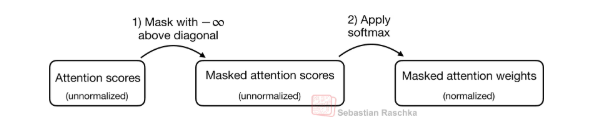

In [83]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[ 2.8991e-01,        -inf,        -inf,        -inf,        -inf,
                -inf,        -inf],
        [ 4.6564e-01,  1.7226e-01,        -inf,        -inf,        -inf,
                -inf,        -inf],
        [ 4.5944e-01,  1.7032e-01,  1.7308e-01,        -inf,        -inf,
                -inf,        -inf],
        [ 2.6416e-01,  1.0239e-01,  1.0365e-01,  1.8641e-02,        -inf,
                -inf,        -inf],
        [ 2.1829e-01,  8.7353e-02,  8.8188e-02,  1.7709e-02,  7.8567e-02,
                -inf,        -inf],
        [ 3.4078e-01,  1.2703e-01,  1.2903e-01,  1.9793e-02,  1.2897e-01,
          7.7567e-03,        -inf],
        [ 2.8596e-01,  8.6908e-02,  9.0049e-02,  5.0612e-05,  1.2153e-01,
         -2.4676e-02,  3.0875e-01]], grad_fn=<MaskedFillBackward0>)


As we can see below, now the attention weights in each row correctly sum to 1 again:

In [84]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529, 0.0000],
        [0.1596, 0.1386, 0.1390, 0.1304, 0.1421, 0.1281, 0.1622]],
       grad_fn=<SoftmaxBackward0>)


,d1,d2,d3
Ganga,0.800,1.040,0.790
is,0.790,0.420,0.770
a,0.380,0.380,0.650
river,0.950,1.170,1.010
blue,0.940,0.880,1.240
in,0.530,0.510,0.870
colour,0.930,0.970,1.100


,d1,d2,d3
Ganga,1.100,0.650,0.810
is,0.530,0.920,0.370
a,0.380,0.710,0.340
river,1.240,0.790,0.910
blue,0.940,1.180,0.730
in,0.520,0.850,0.440
colour,1.040,0.920,0.770


,d1,d2,d3
Ganga,0.890,0.870,1.050
is,0.630,0.710,0.520
a,0.630,0.380,0.470
river,1.070,0.970,1.150
blue,1.160,0.870,0.940
in,0.810,0.480,0.570
colour,1.060,0.870,0.960


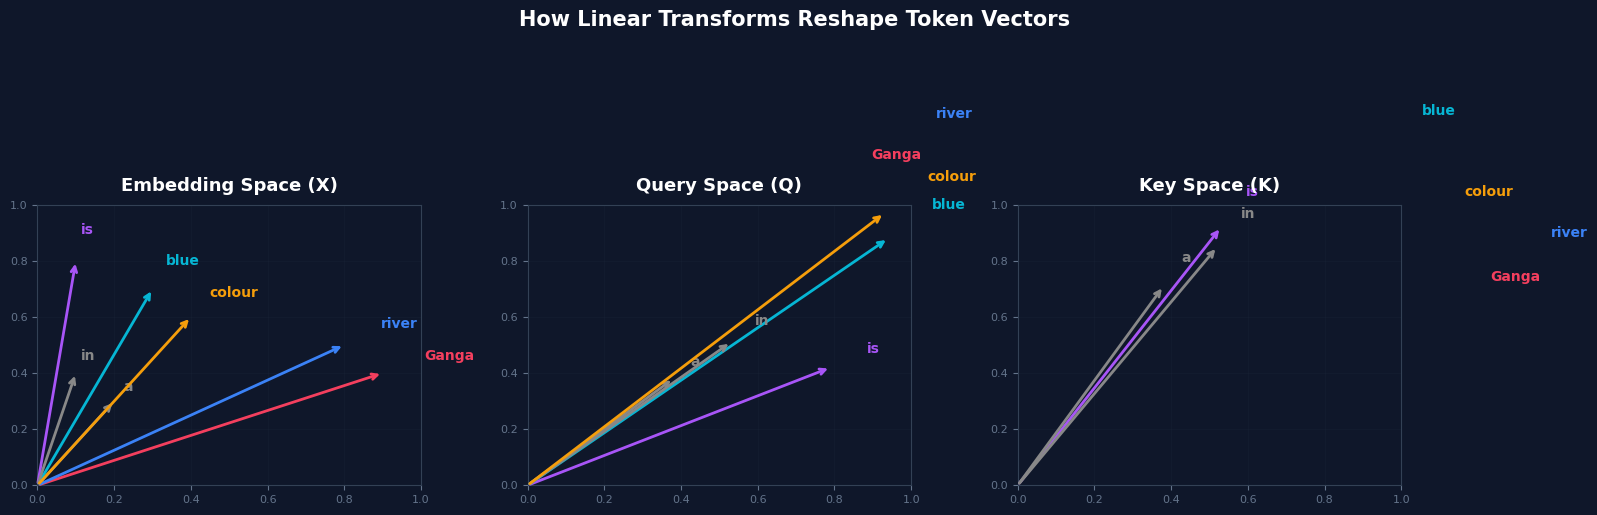

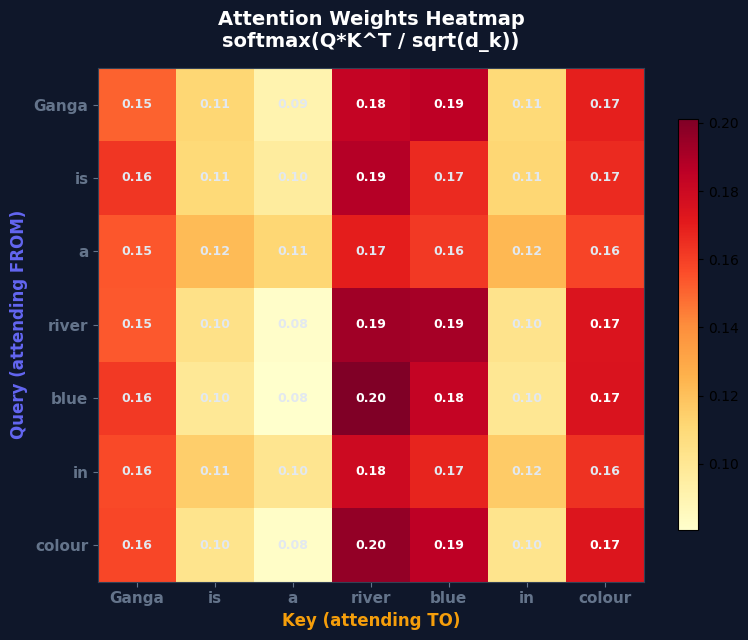

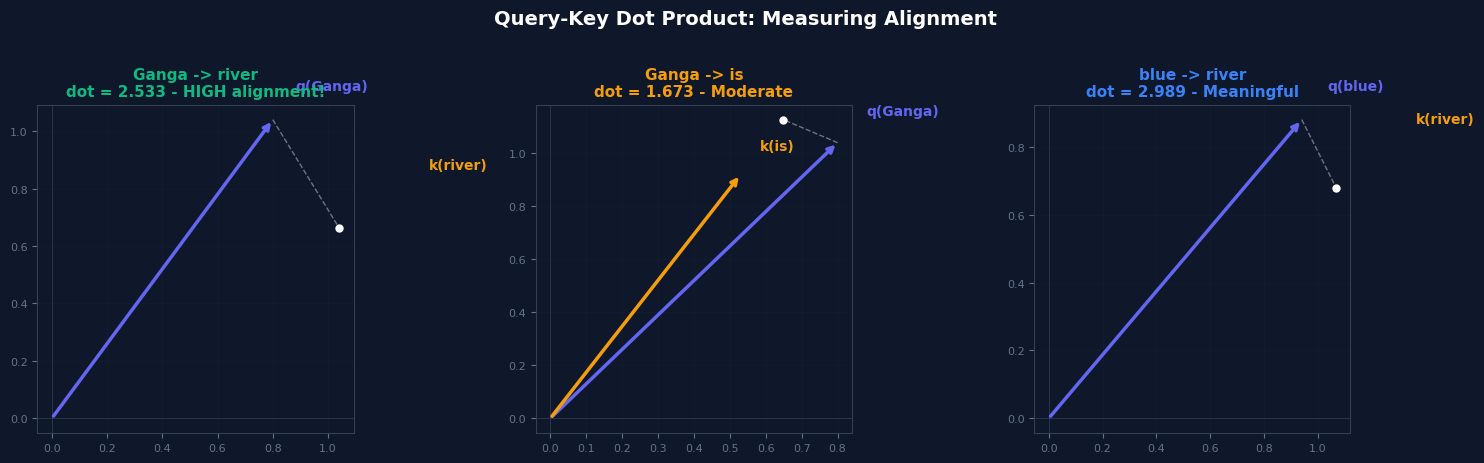

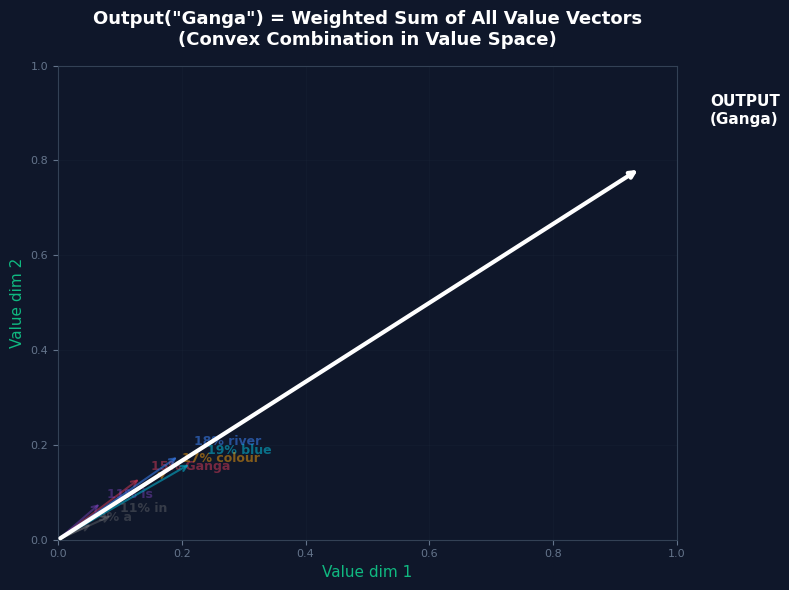

interactive(children=(Dropdown(description='Token:', options=('Ganga', 'is', 'a', 'river', 'blue', 'in', 'colo…

1. Embeddings,Words become vectors,Points in high-dim space
2. × W_Q → Q,What do I need?,Linear transform into need-space
3. × W_K → K,What do I offer?,Linear transform into offer-space
4. × W_V → V,Here is my meaning,Linear transform into content-space
5. Q · Kᵀ,Who has what I need?,Cosine similarity × magnitudes
6. Softmax,How much to listen,Project onto probability simplex
7. Weights · V,Blend by relevance,Convex combination of value vectors


In [85]:
# @title
# ============================================================
# PART 4: INTERACTIVE COMPUTATION & VISUALIZATION
# Paste this in a Colab CODE cell and run it
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as FancyArrowPatch
from IPython.display import display, HTML
import ipywidgets as widgets

# ── DATA ─────────────────────────────────────────────────────
tokens = ["Ganga", "is", "a", "river", "blue", "in", "colour"]
tcols = ["#f43f5e", "#a855f7", "#888888", "#3b82f6", "#06b6d4", "#888888", "#f59e0b"]

X = np.array([
    [0.9,0.4,0.7,0.2],[0.1,0.8,0.2,0.5],[0.2,0.3,0.1,0.6],
    [0.8,0.5,0.9,0.3],[0.3,0.7,0.6,0.8],[0.1,0.4,0.3,0.7],[0.4,0.6,0.8,0.5]])
W_Q = np.array([[.2,.5,.1],[.8,.1,.3],[.4,.7,.6],[.1,.3,.8]])
W_K = np.array([[.5,.2,.4],[.3,.6,.1],[.7,.1,.5],[.2,.8,.3]])
W_V = np.array([[.3,.4,.6],[.1,.7,.2],[.6,.3,.5],[.8,.1,.4]])

Q = X @ W_Q; K = X @ W_K; V = X @ W_V
d_k = Q.shape[1]
scores = Q @ K.T
scaled = scores / np.sqrt(d_k)
def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)
W_attn = softmax(scaled)
output = W_attn @ V

# ── STYLED HEADER ────────────────────────────────────────────
display(HTML("""
<div style="font-family:sans-serif;background:#0f172a;color:#e2e8f0;padding:20px;border-radius:16px;max-width:860px;margin:10px auto;text-align:center">
  <h1 style="font-size:28px;font-weight:800;background:linear-gradient(135deg,#10b981,#3b82f6,#f43f5e);-webkit-background-clip:text;-webkit-text-fill-color:transparent;margin:0">&#x1F3AE; Part 4: Interactive Computation &amp; Visualization</h1>
  <p style="color:#94a3b8;font-size:14px;margin-top:4px">"Ganga is a river blue in colour" &mdash; Full pipeline with plots</p>
</div>
"""))

# ── PRINT MATRICES ───────────────────────────────────────────
def print_matrix(name, mat, emoji, color):
    header = "".join(f"{'d'+str(j+1):>8s}" for j in range(mat.shape[1]))
    rows_html = ""
    for i, tok in enumerate(tokens):
        vals = "".join(f"<td style='padding:4px 8px;font-family:monospace;font-size:12px;color:#e2e8f0;background:{color}15;border:1px solid #334155;text-align:center'>{v:.3f}</td>" for v in mat[i])
        rows_html += f"<tr><td style='padding:4px 8px;color:{tcols[i]};font-weight:700;font-size:12px;text-align:right;border:1px solid #334155'>{tok}</td>{vals}</tr>"
    cols_html = "".join(f"<th style='padding:4px 8px;color:#64748b;font-size:10px;border:1px solid #334155'>d{j+1}</th>" for j in range(mat.shape[1]))
    display(HTML(f"""
    <div style="font-family:sans-serif;background:#0f172a;padding:12px;border-radius:12px;border:2px solid {color}30;margin:8px auto;max-width:500px">
      <p style="color:{color};font-weight:800;font-size:15px;margin:0 0 6px;text-align:center">{emoji} {name} ({mat.shape[0]}&times;{mat.shape[1]})</p>
      <table style="border-collapse:collapse;margin:0 auto"><thead><tr><th style="border:1px solid #334155"></th>{cols_html}</tr></thead><tbody>{rows_html}</tbody></table>
    </div>"""))

print_matrix("Query Matrix (Q = X * W_Q)", Q, "&#x1F50D;", "#6366f1")
print_matrix("Key Matrix (K = X * W_K)", K, "&#x1F511;", "#f59e0b")
print_matrix("Value Matrix (V = X * W_V)", V, "&#x1F4E6;", "#10b981")

# ── PLOT 1: EMBEDDING vs Q vs K SPACES ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f172a')
spaces = [
    ("Embedding Space (X)", X, "#64748b"),
    ("Query Space (Q)", Q, "#6366f1"),
    ("Key Space (K)", K, "#f59e0b"),
]
for ax, (title, mat, col) in zip(axes, spaces):
    ax.set_facecolor('#0f172a')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.axhline(0, color='#334155', lw=0.5); ax.axvline(0, color='#334155', lw=0.5)
    ax.grid(True, alpha=0.1, color='#334155')
    for i, tok in enumerate(tokens):
        ax.annotate("", xy=(mat[i,0], mat[i,1]), xytext=(0,0),
                     arrowprops=dict(arrowstyle="->", color=tcols[i], lw=2))
        ax.text(mat[i,0]*1.12, mat[i,1]*1.12, tok, color=tcols[i],
                fontsize=10, fontweight='bold', ha='left' if mat[i,0]>0 else 'right')
    ax.tick_params(colors='#64748b', labelsize=8)
    for s in ax.spines.values(): s.set_color('#334155')
plt.suptitle("How Linear Transforms Reshape Token Vectors", color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── PLOT 2: ATTENTION HEATMAP ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6.5))
fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#0f172a')
im = ax.imshow(W_attn, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xticklabels(tokens, color='#e2e8f0', fontsize=11, fontweight='bold')
ax.set_yticklabels(tokens, color='#e2e8f0', fontsize=11, fontweight='bold')
ax.set_xlabel("Key (attending TO)", color='#f59e0b', fontsize=12, fontweight='bold')
ax.set_ylabel("Query (attending FROM)", color='#6366f1', fontsize=12, fontweight='bold')
ax.set_title("Attention Weights Heatmap\nsoftmax(Q*K^T / sqrt(d_k))", color='white', fontsize=14, fontweight='bold', pad=15)
for i in range(7):
    for j in range(7):
        v = W_attn[i,j]
        ax.text(j, i, f"{v:.2f}", ha='center', va='center',
                color='white' if v > 0.17 else '#e2e8f0', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.tick_params(colors='#64748b')
for s in ax.spines.values(): s.set_color('#334155')
plt.tight_layout(); plt.show()

# ── PLOT 3: DOT PRODUCT ALIGNMENT ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('#0f172a')
pairs = [
    ("Ganga -> river", 0, 3, "#10b981", "HIGH alignment!"),
    ("Ganga -> is", 0, 1, "#f59e0b", "Moderate"),
    ("blue -> river", 4, 3, "#3b82f6", "Meaningful"),
]
for ax, (title, qi, ki, col, verdict) in zip(axes, pairs):
    ax.set_facecolor('#0f172a')
    qv, kv = Q[qi], K[ki]
    dv = np.dot(qv, kv)
    ax.annotate("", xy=(qv[0], qv[1]), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color="#6366f1", lw=2.5))
    ax.text(qv[0]*1.1, qv[1]*1.1, f"q({tokens[qi]})", color="#6366f1", fontsize=10, fontweight='bold')
    ax.annotate("", xy=(kv[0], kv[1]), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color="#f59e0b", lw=2.5))
    ax.text(kv[0]*1.1, kv[1]*1.1, f"k({tokens[ki]})", color="#f59e0b", fontsize=10, fontweight='bold')
    proj_s = np.dot(qv[:2], kv[:2]) / (np.dot(kv[:2], kv[:2]) + 1e-8)
    pp = kv[:2] * proj_s
    ax.plot([qv[0], pp[0]], [qv[1], pp[1]], '--', color='white', alpha=0.4, lw=1)
    ax.plot(pp[0], pp[1], 'o', color='white', markersize=5)
    ax.axhline(0, color='#334155', lw=0.5); ax.axvline(0, color='#334155', lw=0.5)
    ax.grid(True, alpha=0.1, color='#334155')
    ax.set_title(f"{title}\ndot = {dv:.3f} - {verdict}", color=col, fontsize=11, fontweight='bold')
    ax.tick_params(colors='#64748b', labelsize=8)
    for s in ax.spines.values(): s.set_color('#334155')
plt.suptitle("Query-Key Dot Product: Measuring Alignment", color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── PLOT 4: OUTPUT AS LINEAR COMBINATION ─────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#0f172a')
for i, tok in enumerate(tokens):
    w = W_attn[0, i]
    wv = V[i] * w
    alpha = max(0.3, w * 3)
    ax.annotate("", xy=(wv[0], wv[1]), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=tcols[i], lw=1.5, alpha=alpha))
    ax.text(wv[0]*1.12, wv[1]*1.12, f"{w:.0%} {tok}", color=tcols[i],
            fontsize=9, fontweight='bold', alpha=alpha)
ax.annotate("", xy=(output[0,0], output[0,1]), xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="white", lw=3))
ax.text(output[0,0]*1.12, output[0,1]*1.12, "OUTPUT\n(Ganga)", color="white",
        fontsize=11, fontweight='bold')
ax.axhline(0, color='#334155', lw=0.5); ax.axvline(0, color='#334155', lw=0.5)
ax.grid(True, alpha=0.1, color='#334155')
ax.set_title('Output("Ganga") = Weighted Sum of All Value Vectors\n(Convex Combination in Value Space)',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Value dim 1", color='#10b981', fontsize=11)
ax.set_ylabel("Value dim 2", color='#10b981', fontsize=11)
ax.tick_params(colors='#64748b', labelsize=8)
for s in ax.spines.values(): s.set_color('#334155')
plt.tight_layout(); plt.show()

# ── INTERACTIVE WIDGET ───────────────────────────────────────
def show_attention(query_token="Ganga"):
    qi = tokens.index(query_token)
    sorted_idx = np.argsort(W_attn[qi])[::-1]
    max_w = W_attn[qi].max()

    bars = ""
    for idx in sorted_idx:
        w = W_attn[qi, idx]
        pct = w / max_w * 100
        bars += f"""
        <div style="display:flex;align-items:center;gap:8px;margin:3px 0">
          <span style="min-width:55px;text-align:right;color:{tcols[idx]};font-weight:700;font-size:13px">{tokens[idx]}</span>
          <div style="flex:1;height:22px;background:#1e293b;border-radius:6px;overflow:hidden;border:1px solid #334155">
            <div style="width:{pct}%;height:100%;background:linear-gradient(90deg,{tcols[idx]},{tcols[idx]}80);border-radius:6px;transition:width 0.3s"></div>
          </div>
          <span style="min-width:45px;color:#e2e8f0;font-weight:700;font-size:12px;font-family:monospace">{w:.1%}</span>
        </div>"""

    terms = " + ".join([f"<span style='color:{tcols[j]}'>{W_attn[qi,j]:.2f}*v({tokens[j]})</span>" for j in range(7)])

    display(HTML(f"""
    <div style="font-family:sans-serif;background:#0f172a;padding:16px;border-radius:14px;border:1px solid #334155;max-width:550px;margin:8px auto">
      <p style="color:#3b82f6;font-weight:800;font-size:16px;margin:0 0 10px;text-align:center">&#x1F50D; "{query_token}" attention distribution</p>
      {bars}
      <div style="margin-top:12px;padding:10px;background:#1e1b4b;border-radius:10px;border:1px solid #6366f140">
        <p style="color:#64748b;font-size:10px;margin:0 0 4px">output("{query_token}") =</p>
        <p style="color:#e2e8f0;font-size:11px;margin:0;font-family:monospace;line-height:1.8">{terms}</p>
      </div>
    </div>"""))

dropdown = widgets.Dropdown(options=tokens, value="Ganga", description="Token:", style={"description_width": "initial"})
widgets.interact(show_attention, query_token=dropdown)

# ── SUMMARY ──────────────────────────────────────────────────
display(HTML("""
<div style="font-family:sans-serif;background:linear-gradient(135deg,#1e1b4b,#172554);padding:20px;border-radius:16px;border:1px solid #6366f140;max-width:700px;margin:16px auto;text-align:center">
  <h2 style="color:#e2e8f0;font-size:20px;margin:0 0 12px">&#x1F3AF; The Complete Pipeline Summary</h2>
  <table style="border-collapse:collapse;width:100%;margin:0 auto">
    <tr><td style="padding:6px;color:#64748b;font-weight:800;border-radius:8px;background:#64748b20;font-size:12px">1. Embeddings</td><td style="padding:6px;color:#94a3b8;font-size:11px">Words become vectors</td><td style="padding:6px;color:#64748b;font-size:11px">Points in high-dim space</td></tr>
    <tr><td style="padding:6px;color:#6366f1;font-weight:800;background:#6366f120;font-size:12px">2. &times; W_Q &rarr; Q</td><td style="padding:6px;color:#94a3b8;font-size:11px">What do I need?</td><td style="padding:6px;color:#64748b;font-size:11px">Linear transform into need-space</td></tr>
    <tr><td style="padding:6px;color:#f59e0b;font-weight:800;background:#f59e0b20;font-size:12px">3. &times; W_K &rarr; K</td><td style="padding:6px;color:#94a3b8;font-size:11px">What do I offer?</td><td style="padding:6px;color:#64748b;font-size:11px">Linear transform into offer-space</td></tr>
    <tr><td style="padding:6px;color:#10b981;font-weight:800;background:#10b98120;font-size:12px">4. &times; W_V &rarr; V</td><td style="padding:6px;color:#94a3b8;font-size:11px">Here is my meaning</td><td style="padding:6px;color:#64748b;font-size:11px">Linear transform into content-space</td></tr>
    <tr><td style="padding:6px;color:#ec4899;font-weight:800;background:#ec489920;font-size:12px">5. Q &middot; K&#x1D40;</td><td style="padding:6px;color:#94a3b8;font-size:11px">Who has what I need?</td><td style="padding:6px;color:#64748b;font-size:11px">Cosine similarity &times; magnitudes</td></tr>
    <tr><td style="padding:6px;color:#3b82f6;font-weight:800;background:#3b82f620;font-size:12px">6. Softmax</td><td style="padding:6px;color:#94a3b8;font-size:11px">How much to listen</td><td style="padding:6px;color:#64748b;font-size:11px">Project onto probability simplex</td></tr>
    <tr><td style="padding:6px;color:#f43f5e;font-weight:800;background:#f43f5e20;font-size:12px">7. Weights &middot; V</td><td style="padding:6px;color:#94a3b8;font-size:11px">Blend by relevance</td><td style="padding:6px;color:#64748b;font-size:11px">Convex combination of value vectors</td></tr>
  </table>
  <p style="color:#e2e8f0;font-size:13px;margin:14px 0 0;line-height:1.6"><strong>Self-attention in one sentence:</strong> Three learned linear transforms create three views of each word. Queries and Keys interact through dot products to measure directional alignment. Softmax normalizes into weights. The output is a convex combination of all Value vectors &mdash; a new, context-enriched point in semantic space.</p>
</div>
"""))


## How each token is associated with other tokens

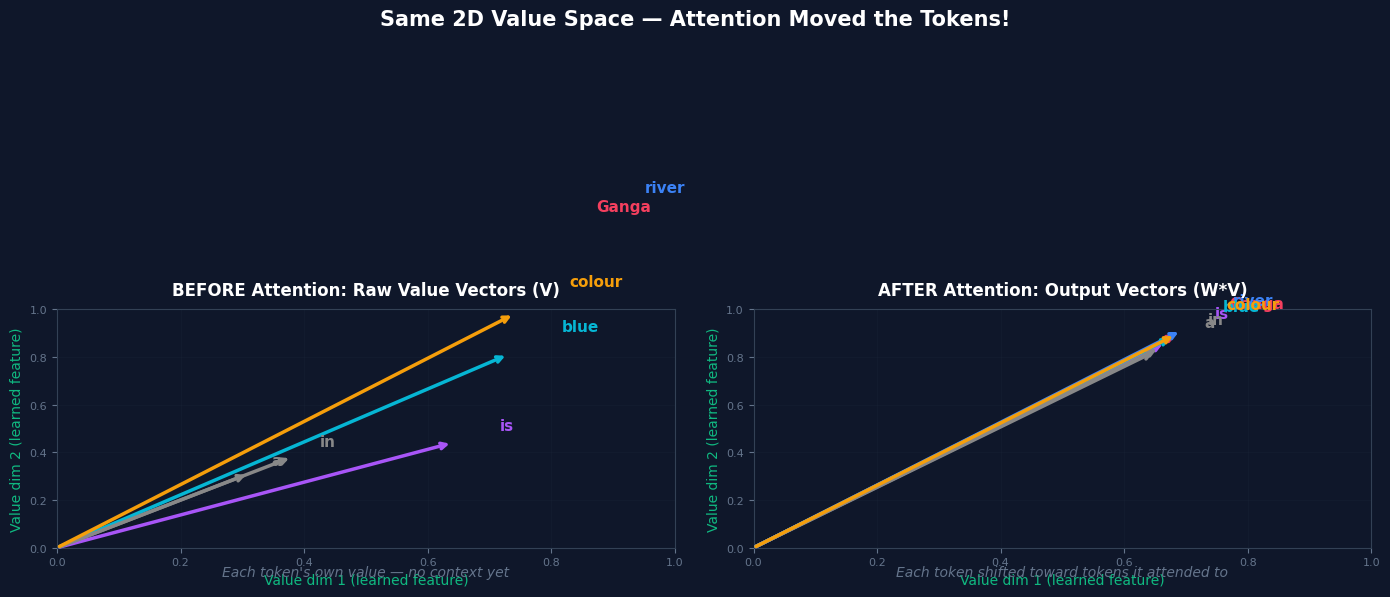

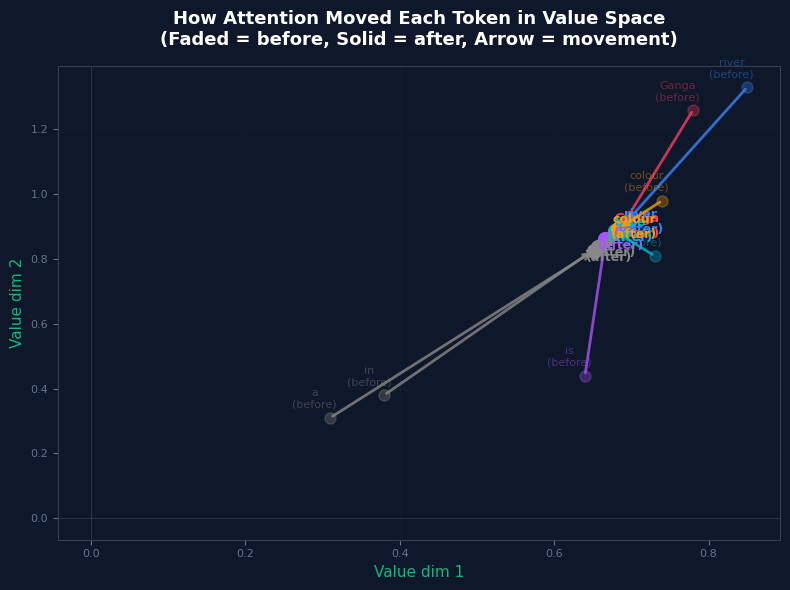

Attention does not change the space.
It changes where each token LIVES within that space.


In [86]:
# @title
# ============================================================
# BONUS: WHAT DO THE OUTPUT DIMENSIONS MEAN?
# Paste this in a Colab CODE cell and run it
# ============================================================
from IPython.display import display, HTML
import numpy as np

# ── Compute with d_k = d_v = 2 as described ─────────────────
tokens = ["Ganga", "is", "a", "river", "blue", "in", "colour"]
tcols = ["#f43f5e","#a855f7","#888","#3b82f6","#06b6d4","#888","#f59e0b"]

# 7 tokens x 3 embedding dims
X = np.array([
    [0.9, 0.4, 0.7],  # Ganga
    [0.1, 0.8, 0.2],  # is
    [0.2, 0.3, 0.1],  # a
    [0.8, 0.5, 0.9],  # river
    [0.3, 0.7, 0.6],  # blue
    [0.1, 0.4, 0.3],  # in
    [0.4, 0.6, 0.8],  # colour
])

# Weight matrices: 3x2 (projecting from 3D to 2D)
W_Q = np.array([[0.3, 0.7],[0.8, 0.2],[0.5, 0.4]])
W_K = np.array([[0.6, 0.1],[0.2, 0.9],[0.4, 0.5]])
W_V = np.array([[0.4, 0.8],[0.7, 0.3],[0.2, 0.6]])

Q = X @ W_Q  # 7x2
K = X @ W_K  # 7x2
V = X @ W_V  # 7x2
d_k = 2

scores = Q @ K.T  # 7x7
scaled = scores / np.sqrt(d_k)
def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)
W_attn = softmax(scaled)  # 7x7
output = W_attn @ V        # 7x2

display(HTML("""
<style>
.dim-wrap{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;background:#0f172a;color:#e2e8f0;padding:24px;border-radius:16px;max-width:880px;margin:10px auto}
.dim-wrap h1{font-size:26px;font-weight:800;background:linear-gradient(135deg,#f43f5e,#6366f1,#10b981);-webkit-background-clip:text;-webkit-text-fill-color:transparent;margin:0 0 4px;text-align:center}
.dim-wrap h2{font-size:20px;font-weight:700;color:#e2e8f0;margin:18px 0 8px;border-bottom:1px solid #1e293b;padding-bottom:6px}
.dim-wrap p{font-size:14px;line-height:1.7;color:#cbd5e1}
.dim-wrap .subtitle{color:#94a3b8;font-size:15px;text-align:center;margin-bottom:16px}
.dim-wrap .card{background:#1e293b;border-radius:12px;padding:14px;border:1px solid #334155;margin:10px 0}
.dim-wrap .flow{display:flex;gap:8px;align-items:center;flex-wrap:wrap;justify-content:center;margin:14px 0}
.dim-wrap .flow-box{padding:10px 14px;border-radius:12px;text-align:center;min-width:80px}
.dim-wrap .flow-arrow{color:#64748b;font-size:22px;font-weight:700}
.dim-wrap .shape{font-family:monospace;font-size:13px;font-weight:700;margin-top:4px}
.dim-wrap .highlight{border-radius:12px;padding:14px;margin:12px 0}
.dim-wrap .grid2{display:flex;gap:14px;flex-wrap:wrap;margin:12px 0}
.dim-wrap .grid2-item{flex:1 1 250px;border-radius:12px;padding:14px}
.dim-wrap .label{font-weight:700;font-size:13px;margin-bottom:6px}
.dim-wrap .dim-table{border-collapse:collapse;width:100%;margin:10px 0}
.dim-wrap .dim-table th,.dim-wrap .dim-table td{padding:8px 10px;font-size:12px;border:1px solid #334155;text-align:center}
.dim-wrap .dim-table th{background:#1e293b;color:#94a3b8;font-weight:600}
.dim-wrap .dim-table tr:nth-child(even){background:#1e293b}
.dim-wrap .dim-table tr:nth-child(odd){background:#0f172a}
.dim-wrap .punchline{background:linear-gradient(135deg,#1e1b4b,#172554);border-radius:14px;padding:16px;border:1px solid #6366f140;text-align:center;margin:16px 0}
.dim-wrap strong{color:#e2e8f0}
.dim-wrap .ann-row{display:flex;gap:6px;align-items:stretch;margin:6px 0}
.dim-wrap .ann-cell{padding:6px 10px;border-radius:6px;font-family:monospace;font-size:12px;text-align:center;display:flex;align-items:center;justify-content:center}
.dim-wrap .brace{display:flex;flex-direction:column;justify-content:center;align-items:center;padding:0 8px;color:#64748b;font-size:11px;font-weight:600}
</style>

<div class="dim-wrap">
  <h1>What Do the Output Dimensions Mean?</h1>
  <p class="subtitle">Understanding the shape (7 &times; 2) of the attention output</p>

  <!-- SHAPE FLOW -->
  <h2>&#x1F4D0; The Shape Journey</h2>
  <div class="flow">
    <div class="flow-box" style="background:#64748b15;border:2px solid #64748b40">
      <div style="font-size:11px;color:#94a3b8">Input X</div>
      <div class="shape" style="color:#e2e8f0">7 &times; 3</div>
      <div style="font-size:10px;color:#64748b">tokens &times; embed</div>
    </div>
    <div class="flow-arrow">&rarr;</div>
    <div class="flow-box" style="background:#6366f115;border:2px solid #6366f140">
      <div style="font-size:11px;color:#6366f1">Q = X&middot;W_Q</div>
      <div class="shape" style="color:#6366f1">7 &times; 2</div>
      <div style="font-size:10px;color:#64748b">tokens &times; d_k</div>
    </div>
    <div class="flow-arrow">&times;</div>
    <div class="flow-box" style="background:#f59e0b15;border:2px solid #f59e0b40">
      <div style="font-size:11px;color:#f59e0b">K&#x1D40;</div>
      <div class="shape" style="color:#f59e0b">2 &times; 7</div>
      <div style="font-size:10px;color:#64748b">d_k &times; tokens</div>
    </div>
    <div class="flow-arrow">=</div>
    <div class="flow-box" style="background:#ec489915;border:2px solid #ec489940">
      <div style="font-size:11px;color:#ec4899">Scores</div>
      <div class="shape" style="color:#ec4899">7 &times; 7</div>
      <div style="font-size:10px;color:#64748b">token &times; token</div>
    </div>
    <div class="flow-arrow">&rarr; softmax &rarr;</div>
    <div class="flow-box" style="background:#3b82f615;border:2px solid #3b82f640">
      <div style="font-size:11px;color:#3b82f6">Weights</div>
      <div class="shape" style="color:#3b82f6">7 &times; 7</div>
      <div style="font-size:10px;color:#64748b">who &times; listens-to</div>
    </div>
    <div class="flow-arrow">&times;</div>
    <div class="flow-box" style="background:#10b98115;border:2px solid #10b98140">
      <div style="font-size:11px;color:#10b981">V</div>
      <div class="shape" style="color:#10b981">7 &times; 2</div>
      <div style="font-size:10px;color:#64748b">tokens &times; d_v</div>
    </div>
    <div class="flow-arrow">=</div>
    <div class="flow-box" style="background:#f43f5e15;border:2px solid #f43f5e40">
      <div style="font-size:11px;color:#f43f5e">Output</div>
      <div class="shape" style="color:#f43f5e">7 &times; 2</div>
      <div style="font-size:10px;color:#64748b">tokens &times; d_v</div>
    </div>
  </div>

  <!-- THE BIG QUESTION -->
  <h2>&#x2753; So What Does 7 &times; 2 Mean?</h2>

  <div class="grid2">
    <div class="grid2-item" style="background:#f43f5e08;border:2px solid #f43f5e30">
      <div class="label" style="color:#f43f5e">The 7 Rows = Tokens (WHO)</div>
      <p style="font-size:13px">Each row is one word's <strong>new, context-enriched representation</strong>. Row 0 = "Ganga" after absorbing context from the entire sentence. Before attention, "Ganga" only knew about itself. After attention, it carries blended meaning from "river", "blue", "colour", etc.</p>
    </div>
    <div class="grid2-item" style="background:#10b98108;border:2px solid #10b98130">
      <div class="label" style="color:#10b981">The 2 Columns = Value Features (WHAT)</div>
      <p style="font-size:13px">These are the <strong>value space dimensions</strong> &mdash; learned abstract feature channels that W_V created. They come entirely from V. Think of them as "aspects of meaning" that the model learned are useful for downstream tasks. They are NOT the original embedding dimensions anymore.</p>
    </div>
  </div>

  <!-- ANALOGY -->
  <h2>&#x1F9D1; Human Analogy: The Party Report Card</h2>
  <div class="card">
    <p>Imagine after the cocktail party, each person fills out a <strong>2-question report card</strong>:</p>
    <div style="margin:10px 0;display:flex;gap:10px;flex-wrap:wrap">
      <div style="flex:1 1 200px;padding:10px;background:#10b98110;border:1px solid #10b98130;border-radius:10px">
        <p style="color:#10b981;font-weight:700;font-size:13px;margin:0 0 4px">Feature Dim 1 (learned)</p>
        <p style="font-size:12px;margin:0">Could capture: <em>"How much entity/noun-ness did I absorb?"</em></p>
      </div>
      <div style="flex:1 1 200px;padding:10px;background:#3b82f610;border:1px solid #3b82f630;border-radius:10px">
        <p style="color:#3b82f6;font-weight:700;font-size:13px;margin:0 0 4px">Feature Dim 2 (learned)</p>
        <p style="font-size:12px;margin:0">Could capture: <em>"How much descriptor/property meaning did I absorb?"</em></p>
      </div>
    </div>
    <p style="font-size:13px">Before the party, "Ganga" had its own raw answers [0.62, 0.98]. After the party (attention), "Ganga" updated its answers based on conversations &mdash; now blended with "river" and "blue" responses. <strong>Same 2 questions, but richer answers.</strong></p>
  </div>

  <!-- GEOMETRIC VIEW -->
  <h2>&#x1F4D0; Geometric View: What Happened to the Dimensions?</h2>
  <div class="card">
    <p><strong>Original embedding:</strong> 3 dimensions &mdash; these encoded raw word identity (position in vocabulary space).</p>
    <p style="margin-top:6px"><strong>Value space:</strong> 2 dimensions &mdash; W_V <em>projected</em> from 3D to 2D. This is a deliberate compression. Not all original information is needed for the "content payload." W_V learned which 2D subspace best captures the <strong>transferable meaning</strong> that other tokens need to receive.</p>
    <p style="margin-top:6px"><strong>Output:</strong> Still 2 dimensions &mdash; but now each token's 2D vector is a <strong>convex combination</strong> of everyone's value vectors. The axes are the same as V-space; the position within that space shifted based on who was attended to.</p>
  </div>

  <div class="highlight" style="background:#6366f110;border:1px solid #6366f130">
    <p style="color:#a5b4fc;font-size:13px"><strong>Key insight:</strong> The 2 output dimensions are the <strong>same axes as V-space</strong>. Attention did not change the axes &mdash; it changed <strong>where each token sits</strong> along those axes by blending with other tokens. The dimensionality (2) was set by d_v = number of columns in W_V.</p>
  </div>

  <!-- 3D to 2D -->
  <h2>&#x1F50D; Why 3D &rarr; 2D? (Compression is a Feature)</h2>
  <div class="grid2">
    <div class="grid2-item" style="background:#1e293b;border:1px solid #334155">
      <div class="label" style="color:#f59e0b">In our toy example</div>
      <p style="font-size:13px">We went from d_model=3 to d_v=2. This forces W_V to learn which 2D slice of the 3D space carries the most useful content for the attention output.</p>
    </div>
    <div class="grid2-item" style="background:#1e293b;border:1px solid #334155">
      <div class="label" style="color:#a855f7">In real Transformers (Multi-Head)</div>
      <p style="font-size:13px">With d_model=512 and h=8 heads, each head uses d_v = 512/8 = 64. Each head captures a different 64D "view" of meaning. Then all 8 heads are <strong>concatenated</strong> back to 512D. So the compression is per-head, and the full representation is reconstructed.</p>
    </div>
  </div>

  <!-- MULTI HEAD CONNECTION -->
  <h2>&#x1F9E9; Connection to Multi-Head Attention</h2>
  <div class="card">
    <p>In practice, the "small d_v" is not information loss &mdash; it is <strong>information partitioning</strong>:</p>
    <div style="margin:10px 0;display:flex;gap:6px;flex-wrap:wrap;justify-content:center">
      <div style="padding:8px 14px;background:#6366f120;border:1px solid #6366f140;border-radius:10px;text-align:center">
        <div style="color:#6366f1;font-weight:700;font-size:12px">Head 1</div>
        <div style="font-family:monospace;font-size:11px;color:#94a3b8">7 &times; 64</div>
        <div style="font-size:10px;color:#64748b">syntax</div>
      </div>
      <div style="padding:8px 14px;background:#f59e0b20;border:1px solid #f59e0b40;border-radius:10px;text-align:center">
        <div style="color:#f59e0b;font-weight:700;font-size:12px">Head 2</div>
        <div style="font-family:monospace;font-size:11px;color:#94a3b8">7 &times; 64</div>
        <div style="font-size:10px;color:#64748b">coreference</div>
      </div>
      <div style="padding:8px 14px;background:#10b98120;border:1px solid #10b98140;border-radius:10px;text-align:center">
        <div style="color:#10b981;font-weight:700;font-size:12px">Head 3</div>
        <div style="font-family:monospace;font-size:11px;color:#94a3b8">7 &times; 64</div>
        <div style="font-size:10px;color:#64748b">semantics</div>
      </div>
      <div style="color:#64748b;display:flex;align-items:center;font-size:16px;font-weight:700">&hellip;</div>
      <div style="padding:8px 14px;background:#f43f5e20;border:1px solid #f43f5e40;border-radius:10px;text-align:center">
        <div style="color:#f43f5e;font-weight:700;font-size:12px">Head 8</div>
        <div style="font-family:monospace;font-size:11px;color:#94a3b8">7 &times; 64</div>
        <div style="font-size:10px;color:#64748b">position</div>
      </div>
    </div>
    <div style="text-align:center;margin:8px 0">
      <span style="color:#64748b;font-size:14px;font-weight:700">&darr; Concatenate &darr;</span>
    </div>
    <div style="text-align:center;padding:10px;background:#a855f720;border:1px solid #a855f740;border-radius:10px">
      <span style="color:#a855f7;font-weight:700;font-size:14px">Final Output: 7 &times; 512</span>
      <span style="color:#94a3b8;font-size:12px;display:block;margin-top:2px">(back to full d_model &mdash; no information lost!)</span>
    </div>
  </div>

  <!-- PUNCHLINE -->
  <div class="punchline">
    <p style="font-size:14px;line-height:1.8">
      <strong style="color:#f43f5e">The 7 rows</strong> = each token now context-aware (blended with relevant neighbors)<br>
      <strong style="color:#10b981">The 2 columns</strong> = learned feature channels from V-space (what W_V decided is useful to carry forward)<br>
      <strong style="color:#6366f1">The transformation</strong> = same V-space axes, but each token <em>moved</em> toward the value vectors it attended to<br><br>
      &#x1F3AF; <strong>Attention does not change the space. It changes where each token lives within that space.</strong>
    </p>
  </div>
</div>
"""))

# ── VISUALIZATION: Before vs After in Value Space ────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f172a')

for ax, (title, mat, note) in zip(axes, [
    ("BEFORE Attention: Raw Value Vectors (V)", V, "Each token's own value — no context yet"),
    ("AFTER Attention: Output Vectors (W*V)", output, "Each token shifted toward tokens it attended to")
]):
    ax.set_facecolor('#0f172a')
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.axhline(0, color='#334155', lw=0.5)
    ax.axvline(0, color='#334155', lw=0.5)
    ax.grid(True, alpha=0.1, color='#334155')

    for i, tok in enumerate(tokens):
        ax.annotate("", xy=(mat[i,0], mat[i,1]), xytext=(0,0),
                     arrowprops=dict(arrowstyle="->", color=tcols[i], lw=2.5))
        ax.text(mat[i,0]*1.12, mat[i,1]*1.12, tok, color=tcols[i],
                fontsize=11, fontweight='bold',
                ha='left' if mat[i,0] > 0 else 'right')

    ax.set_xlabel("Value dim 1 (learned feature)", color='#10b981', fontsize=10)
    ax.set_ylabel("Value dim 2 (learned feature)", color='#10b981', fontsize=10)
    ax.tick_params(colors='#64748b', labelsize=8)
    for s in ax.spines.values():
        s.set_color('#334155')

    # Add note
    ax.text(0.5, -0.12, note, transform=ax.transAxes, ha='center',
            color='#64748b', fontsize=10, style='italic')

plt.suptitle("Same 2D Value Space — Attention Moved the Tokens!",
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Show movement arrows
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')
ax.axhline(0, color='#334155', lw=0.5)
ax.axvline(0, color='#334155', lw=0.5)
ax.grid(True, alpha=0.1, color='#334155')

for i, tok in enumerate(tokens):
    # Ghost of original position
    ax.plot(V[i,0], V[i,1], 'o', color=tcols[i], alpha=0.3, markersize=8)
    ax.text(V[i,0]-0.02, V[i,1]+0.03, f"{tok}\n(before)", color=tcols[i],
            fontsize=8, alpha=0.4, ha='center')

    # Arrow from before to after
    dx = output[i,0] - V[i,0]
    dy = output[i,1] - V[i,1]
    ax.annotate("", xy=(output[i,0], output[i,1]), xytext=(V[i,0], V[i,1]),
                arrowprops=dict(arrowstyle="->", color=tcols[i], lw=2, alpha=0.8))

    # New position
    ax.plot(output[i,0], output[i,1], 'o', color=tcols[i], markersize=10)
    ax.text(output[i,0]+0.02, output[i,1]-0.03, f"{tok}\n(after)", color=tcols[i],
            fontsize=9, fontweight='bold', ha='center')

ax.set_title("How Attention Moved Each Token in Value Space\n(Faded = before, Solid = after, Arrow = movement)",
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Value dim 1", color='#10b981', fontsize=11)
ax.set_ylabel("Value dim 2", color='#10b981', fontsize=11)
ax.tick_params(colors='#64748b', labelsize=8)
for s in ax.spines.values():
    s.set_color('#334155')
plt.tight_layout()
plt.show()

print("Attention does not change the space.")
print("It changes where each token LIVES within that space.")

## Introducing dropout layer

In [87]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) # dropout rate of 50%
example = torch.ones(6, 6) # create a matrix of ones
# We should see half of the value to be zero but at random places
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [88]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4925, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.3941, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2779, 0.0000, 0.2842, 0.2563, 0.0000]],
       grad_fn=<MulBackward0>)


## Coding everything together

- `d_in`- Input dimension for matrix
- `d_out` - Output dimension
- `W_Query`- Weight matrix for query with dimension(d_in,d_out)
- `W_Key` - Weight matrix for key with dimension(d_in,d_out)
- `W_value`- Weight matrix for value with dimension (d_in,d_out)
- `self.dropout` - Dropout ration
- `keys` - Dot product between input x and W_key
- `queries`- Dot product between input x and W_Query
 - `values` - Dot product between input x and W_value
 - `attn_scores` - queries @ keys.transpose
 - `attn_weights` - Softmax of attn_scores with row level
  - `context_vec` - attn_weights @ values


In [89]:
batch = torch.stack((inputs, inputs), dim=0)
batch

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500],
         [0.9500, 0.0800, 0.5300]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500],
         [0.9500, 0.0800, 0.5300]]])

In [90]:
print(batch.shape) #

torch.Size([2, 7, 3])


In [91]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        # For inputs where `num_tokens` exceeds `context_length`, this will result in errors
        # in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)

context_length = batch.shape[1]# This is the actual sentence length
ca = CausalAttention(d_in, d_out, context_length, 0.0)

context_vecs = ca(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081],
         [-0.5449, -0.0807]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081],
         [-0.5449, -0.0807]]], grad_fn=<UnsafeViewBackward0>)
context_vecs.shape: torch.Size([2, 7, 2])


## Extending it to multi head attention

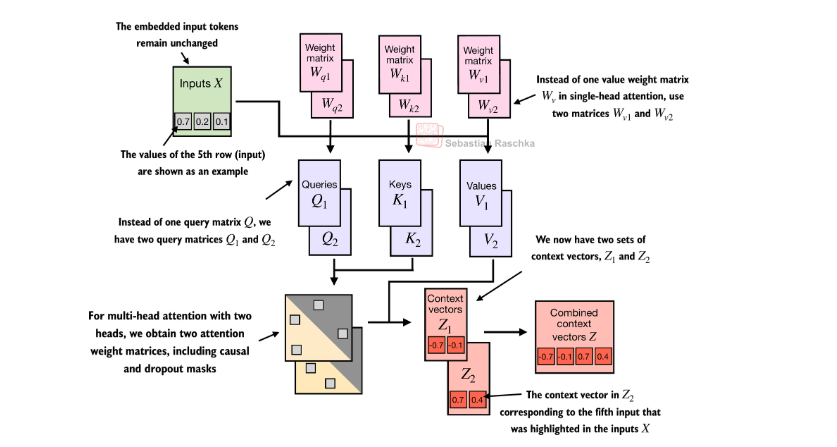

## We simply stack multiple single-head attention modules to obtain a multi-head attention module:

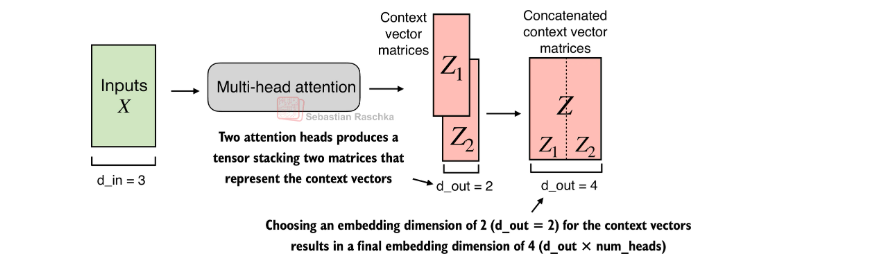

In [92]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # As in `CausalAttention`, for inputs where `num_tokens` exceeds `context_length`,
        # this will result in errors in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out = 4
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490],
         [-0.0032,  0.2966, -0.0705, -0.3675]],

        [[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490],
         [-0.0032,  0.2966, -0.0705, -0.3675]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 7, 4])


## Positional Encoding & Multiplicative Invariance

Let me build this up carefully with your exact toy example.

Token matrix X (2×3):

         d1    d2    d3

tom  → [ 0.9,  0.6,  0.3 ]

jerry→  [ 0.5,  0.8,  0.2 ]

What is Multiplicative Invariance?
In pure attention, the score between two tokens is:

score(i, j) = Xᵢ · Xⱼᵀ

The problem: matrix multiplication is commutative in score computation — swapping rows doesn't change the set of scores, only their assignment. The model has no inherent way to know token order.

Concretely:

score(tom, jerry) = [0.9, 0.6, 0.3] · [0.5, 0.8, 0.2]ᵀ
                  = (0.9×0.5) + (0.6×0.8) + (0.3×0.2)
                  = 0.45 + 0.48 + 0.06 = 0.99
                  

score(jerry, tom) = [0.5, 0.8, 0.2] · [0.9, 0.6, 0.3]ᵀ
                  = 0.45 + 0.48 + 0.06 = 0.99  ← SAME!

"tom jerry" and "jerry tom" produce identical attention scores.
The model is blind to order.

Positional Encoding (Sinusoidal)

The formula:

PE(pos, 2i)   = sin(pos / 10000^(2i/d))


PE(pos, 2i+1) = cos(pos / 10000^(2i/d))

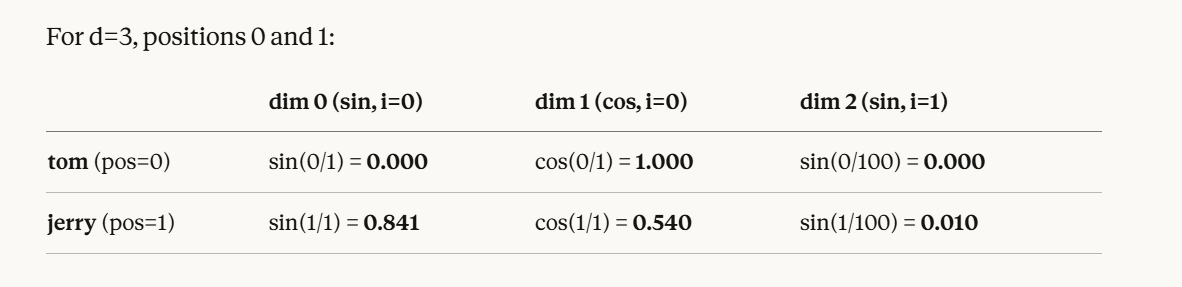

Adding PE to Embeddings

X' = X + PE

         d1              d2              d3
         
tom  → [0.9+0.000,  0.6+1.000,  0.3+0.000] = [0.900, 1.600, 0.300]

jerry→  [0.5+0.841,  0.8+0.540,  0.2+0.010] = [1.341, 1.340, 0.210]

Now Recompute Attention Scores

Original order: "tom jerry"

score(tom→jerry) = [0.900, 1.600, 0.300] · [1.341, 1.340, 0.210]ᵀ

= (0.900×1.341) + (1.600×1.340) + (0.300×0.210)

= 1.207 + 2.144 + 0.063

= 3.414

Swapped order: "jerry tom" (jerry gets pos=0, tom gets pos=1)

jerry (pos=0) → [0.5+0.000, 0.8+1.000, 0.2+0.000] = [0.500, 1.800, 0.200]

tom   (pos=1) → [0.9+0.841, 0.6+0.540, 0.3+0.010] = [1.741, 1.140, 0.310]


score(jerry→tom) = [0.500, 1.800, 0.200] · [1.741, 1.140, 0.310]ᵀ

= (0.500×1.741) + (1.800×1.140) + (0.200×0.310)

= 0.871 + 2.052 + 0.062

= 2.985

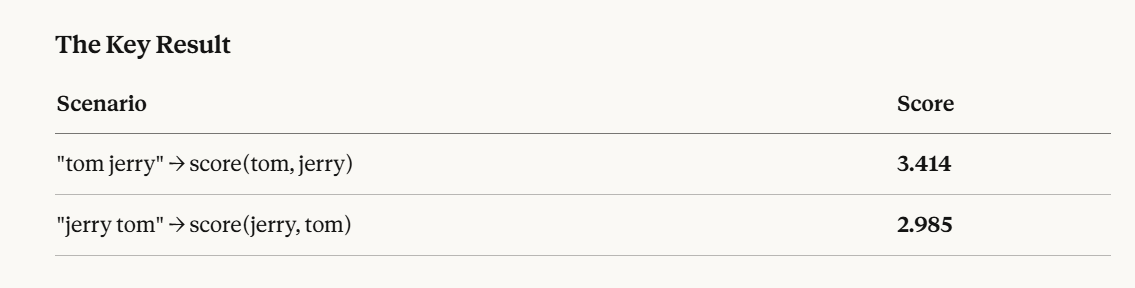

## Scores are now different

Why Does This Work Intuitively?

Without PE:  tom = [0.9, 0.6, 0.3]  ← just semantics


With PE:     

            tom@pos0 = [0.900, 1.600, 0.300]  ← semantics + WHERE it is

            tom@pos1 = [1.741, 1.140, 0.310]  ← different position = different vector

Each token's vector is uniquely fingerprinted by its position. Since dot-product attention depends on the actual vector values, swapping positions changes the vectors, which changes the scores — breaking the multiplicative invariance.


The sinusoidal pattern is specifically chosen so that:

Every position gets a unique encoding
The relationship between positions is smooth and consistent
The model can generalize to sequence lengths not seen during training